# House Price Prediction & Feature Analysis

## Project overview

This case study investigates which property characteristics are most strongly associated with residential sale prices and develops regression-based prediction models.

The dataset contains **21,597 property records** and includes variables such as price, bedrooms, bathrooms, living area, lot size, floors, waterfront indicator, view, condition, grade, year built, renovation year and neighbourhood-related size measures.

**Business-style question:** Which property characteristics explain the largest share of price variation, and how does data cleaning affect model performance?

**Methods:** exploratory data analysis, correlation analysis, linear regression, residual diagnostics, outlier treatment, stepwise feature selection, prediction intervals, polynomial regression, XGBoost and SHAP.

### Selected findings from the analysis
- Living area and property grade show strong positive relationships with price.
- The initial linear model reported **R² ≈ 0.654**.
- After removing observations with large residuals, the model reported **R² ≈ 0.688**.
- The original analysis also identified multicollinearity and wide prediction intervals as important limitations.


## Dataset and objective

The analysis uses a residential property sales dataset with detailed structural and quality characteristics. The objective is to explore price drivers, build regression models and assess how preprocessing choices influence model fit and interpretation.

## Load the dataset
We start by loading the dataset and displaying its first few rows to get an initial look at the data.


In [ ]:
from pathlib import Path

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

import pandas as pd

# Load the dataset
file_path = '../data/kc_house_data.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the dataframe to understand its structure
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,1340,5650
1,6414100192,12/9/2014,538000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,1690,7639
2,5631500400,2/25/2015,180000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,2720,8062
3,2487200875,12/9/2014,604000,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,1360,5000
4,1954400510,2/18/2015,510000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,1800,7503


This step helps us understand the structure and contents of the dataset by showing a sample of the data. It also ensures the data has been loaded correctly.

*   id: A unique identifier for each house.
*   date: The date when the house was sold.
*   price: The sale price of the house.
*   bedrooms: The number of bedrooms in the house.
*   bathrooms: The number of bathrooms in the house.
*   sqft_living: The living area size in square feet.
*   sqft_lot: The lot size in square feet.
*   floors: The number of floors in the house.
*   waterfront: Whether the house has a waterfront view (0 or 1).
*   view: An index from 0 to 4 of how good the view of the property is.
*   condition: An index from 1 to 5 on the condition of the house.
*   grade: An index from 1 to 13, where 1-3 falls short of building code and 7 has an average level of construction and design.
*   sqft_above: The square footage of the house apart from the basement.
*   sqft_basement: The square footage of the basement.
*   yr_built: The year the house was built.
*   yr_renovated: The year the house was renovated (0 if never).
*   sqft_living15: The living area size of the nearest 15 neighbors in square feet.
*   sqft_lot15: The lot size of the nearest 15 neighbors in square feet.

**Specific Observations:**
*   Price Variability:
Market values of houses are diverse; they range from 221,900 USD to 604,000 USD in the first five rows.

*   Bedrooms and Bathrooms:
There are 2 to 4 bedrooms.
The bathroom ranges from as low as 1.0 up to around 3.

*   Square Footage:
Living area (sqft_living) ranges from 770 to 2570 square feet.
Lot size (sqft_lot) also shows substantial variability from 5000 to 10000 square feet.

*   Age and Renovation: The houses have different construction years from 1933 to 1987. Only one of the houses has undergone renovation and that was in 1991, which was built in 1951.

*   Waterfront: All the houses in this subset have 0, meaning no house features a waterfront view.

*   View, Condition, Grade: These columns show the quality and design level of the houses with average values suggesting standard conditions and design.

The dataset reflects different focusing forms and market groups because it represents a degree of variance in housing characteristics.

## Convert area measurements to square metres

Converting US units of measurement to European standards promotes international understanding and facilitates comparative analysis of real estate data in Europe.

In this context, we'll convert the following units:
*  Square feet (sqft) to square meters (sqm).

In [ ]:
df = pd.read_csv(file_path)

# Conversion factor
sqft_to_sqm = 0.092903

# Converting square footage columns to square meters
df['sqft_living'] = df['sqft_living'] * sqft_to_sqm
df['sqft_lot'] = df['sqft_lot'] * sqft_to_sqm
df['sqft_above'] = df['sqft_above'] * sqft_to_sqm
df['sqft_basement'] = df['sqft_basement'] * sqft_to_sqm
df['sqft_living15'] = df['sqft_living15'] * sqft_to_sqm
df['sqft_lot15'] = df['sqft_lot15'] * sqft_to_sqm

# Renaming columns to reflect new units
df.rename(columns={
    'sqft_living': 'sqm_living',
    'sqft_lot': 'sqm_lot',
    'sqft_above': 'sqm_above',
    'sqft_basement': 'sqm_basement',
    'sqft_living15': 'sqm_living15',
    'sqft_lot15': 'sqm_lot15'
}, inplace=True)

# Save the new dataframe to a CSV file
new_file_path = '../data/kc_house_data_eu_units.csv'
df.to_csv(new_file_path, index=False)

# Display the first few rows to confirm the changes
df.head()

,id,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,sqm_living15,sqm_lot15
0,7129300520,10/13/2014,221900,3,1.00,109.62554,524.901950,1.0,0,0,3,7,109.62554,0.00000,1955,0,124.49002,524.901950
1,6414100192,12/9/2014,538000,3,2.25,238.76071,672.803526,2.0,0,0,3,7,201.59951,37.16120,1951,1991,157.00607,709.686017
2,5631500400,2/25/2015,180000,2,1.00,71.53531,929.030000,1.0,0,0,3,6,71.53531,0.00000,1933,0,252.69616,748.983986
3,2487200875,12/9/2014,604000,4,3.00,182.08988,464.515000,1.0,0,0,5,7,97.54815,84.54173,1965,0,126.34808,464.515000
4,1954400510,2/18/2015,510000,3,2.00,156.07704,750.656240,1.0,0,0,3,8,156.07704,0.00000,1987,0,167.22540,697.051209


## Dataset overview

We will get an overview of the dataset, including its shape, data types, and summary statistics.

*  df.info() provides a summary of the dataset, including the total number of non-null entries per column and their data types. This helps identify potential issues such as missing values or incorrect data types.
*  df.describe() provides summary statistics for numerical columns, including count, mean, standard deviation, min, max, and quartiles. This gives a high-level understanding of the data distribution and potential outliers.

In [ ]:
new_file_path = '../data/kc_house_data_eu_units.csv'
df.to_csv(new_file_path, index=False)

# Display basic information about the dataset
df.info()

# Display summary statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            21597 non-null  int64  
 1   date          21597 non-null  object 
 2   price         21597 non-null  int64  
 3   bedrooms      21597 non-null  int64  
 4   bathrooms     21597 non-null  float64
 5   sqm_living    21597 non-null  float64
 6   sqm_lot       21597 non-null  float64
 7   floors        21597 non-null  float64
 8   waterfront    21597 non-null  int64  
 9   view          21597 non-null  int64  
 10  condition     21597 non-null  int64  
 11  grade         21597 non-null  int64  
 12  sqm_above     21597 non-null  float64
 13  sqm_basement  21597 non-null  float64
 14  yr_built      21597 non-null  int64  
 15  yr_renovated  21597 non-null  int64  
 16  sqm_living15  21597 non-null  float64
 17  sqm_lot15     21597 non-null  float64
dtypes: float64(8), int64(9), o

,id,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,sqm_living15,sqm_lot15
count,2.159700e+04,2.159700e+04,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,4.580474e+09,5.402966e+05,3.373200,2.115826,193.268141,1402.780372,1.494096,0.007547,0.234292,3.409825,7.657915,166.166012,27.102128,1970.999676,84.464787,184.562987,1185.282813
std,2.876736e+09,3.673681e+05,0.926299,0.768984,85.294813,3847.358204,0.539683,0.086549,0.766390,0.650546,1.173200,76.901365,41.125167,29.375234,401.821438,63.659967,2533.877481
min,1.000102e+06,7.800000e+04,1.000000,0.500000,34.374110,48.309560,1.000000,0.000000,0.000000,1.000000,3.000000,34.374110,0.000000,1900.000000,0.000000,37.068297,60.479853
25%,2.123049e+09,3.220000e+05,3.000000,1.750000,132.851290,468.231120,1.000000,0.000000,0.000000,3.000000,7.000000,110.554570,0.000000,1951.000000,0.000000,138.425470,473.805300
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,177.444730,707.735054,1.500000,0.000000,0.000000,3.000000,7.000000,144.928680,0.000000,1975.000000,0.000000,170.941520,707.920860
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,236.902650,992.668555,2.000000,0.000000,0.000000,4.000000,8.000000,205.315630,52.025680,1997.000000,0.000000,219.251080,936.740949
max,9.900000e+09,7.700000e+06,33.000000,8.000000,1257.906620,153416.205177,3.500000,1.000000,4.000000,5.000000,13.000000,874.217230,447.792460,2015.000000,2015.000000,576.927630,80937.093600


No missing values are present in any column.
Most columns are int64 or float64, except for date, which has been converted to datetime - object.

*  **High variability:**
There is a wide range of prices, square footage and other features, showing that the housing market is diverse.

*  **Emissions:**
Some values ​​stand out as extreme, especially in price, number of bedrooms and lot size. This could be a luxury or very large property.

*  **Condition and class:**
Most homes are in average condition and have a rating that suggests they are of average to above average quality.

*  **Neighborhoods:**
The sqm_living15 and sqm_lot15 columns provide us with information about the living area and lot sizes of nearby houses, which can be useful in predicting house prices.

The dataset reflects different focusing forms and market groups because it represents a degree of variance in housing characteristics.



## Variable types

Identifying between continuous and category variables.
Based on their values, we may distinguish between continuous and categorical variables in a particular data collection.

In [ ]:
# Identify categorical variables
categorical_vars = ['waterfront', 'view', 'condition', 'grade']

# Identify continuous variables
continuous_vars = ['price', 'bedrooms', 'bathrooms', 'sqm_living', 'sqm_lot', 'floors',
                   'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated',
                   'sqm_living15', 'sqm_lot15']

# Display the lists of categorical and continuous variables
print("Categorical Variables:", categorical_vars)
print("Continuous Variables:", continuous_vars)

Categorical Variables: ['waterfront', 'view', 'condition', 'grade']
Continuous Variables: ['price', 'bedrooms', 'bathrooms', 'sqm_living', 'sqm_lot', 'floors', 'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'sqm_living15', 'sqm_lot15']


*  **Categorical variables** - represent individual categories that are not numeric or have a limited number of unique values, these include waterfront, view, condition and grade.

*  **Continuous variables** are measurable quantities and take a range of numerical values, these include price, bedrooms, bathrooms, sqm_living, sqm_lot,floors, sqm_above, sqm_basement, yr_built, yr_renovated, sqm_living15 and sqm_lot15.

## Exploratory visualisation

Let's create visualizations for both categorical and continuous variables to better understand the data distribution and relationships.

*  **Visualizing Categorical Variables**

We will use bar charts to visualize the frequency of each category in the categorical variables.

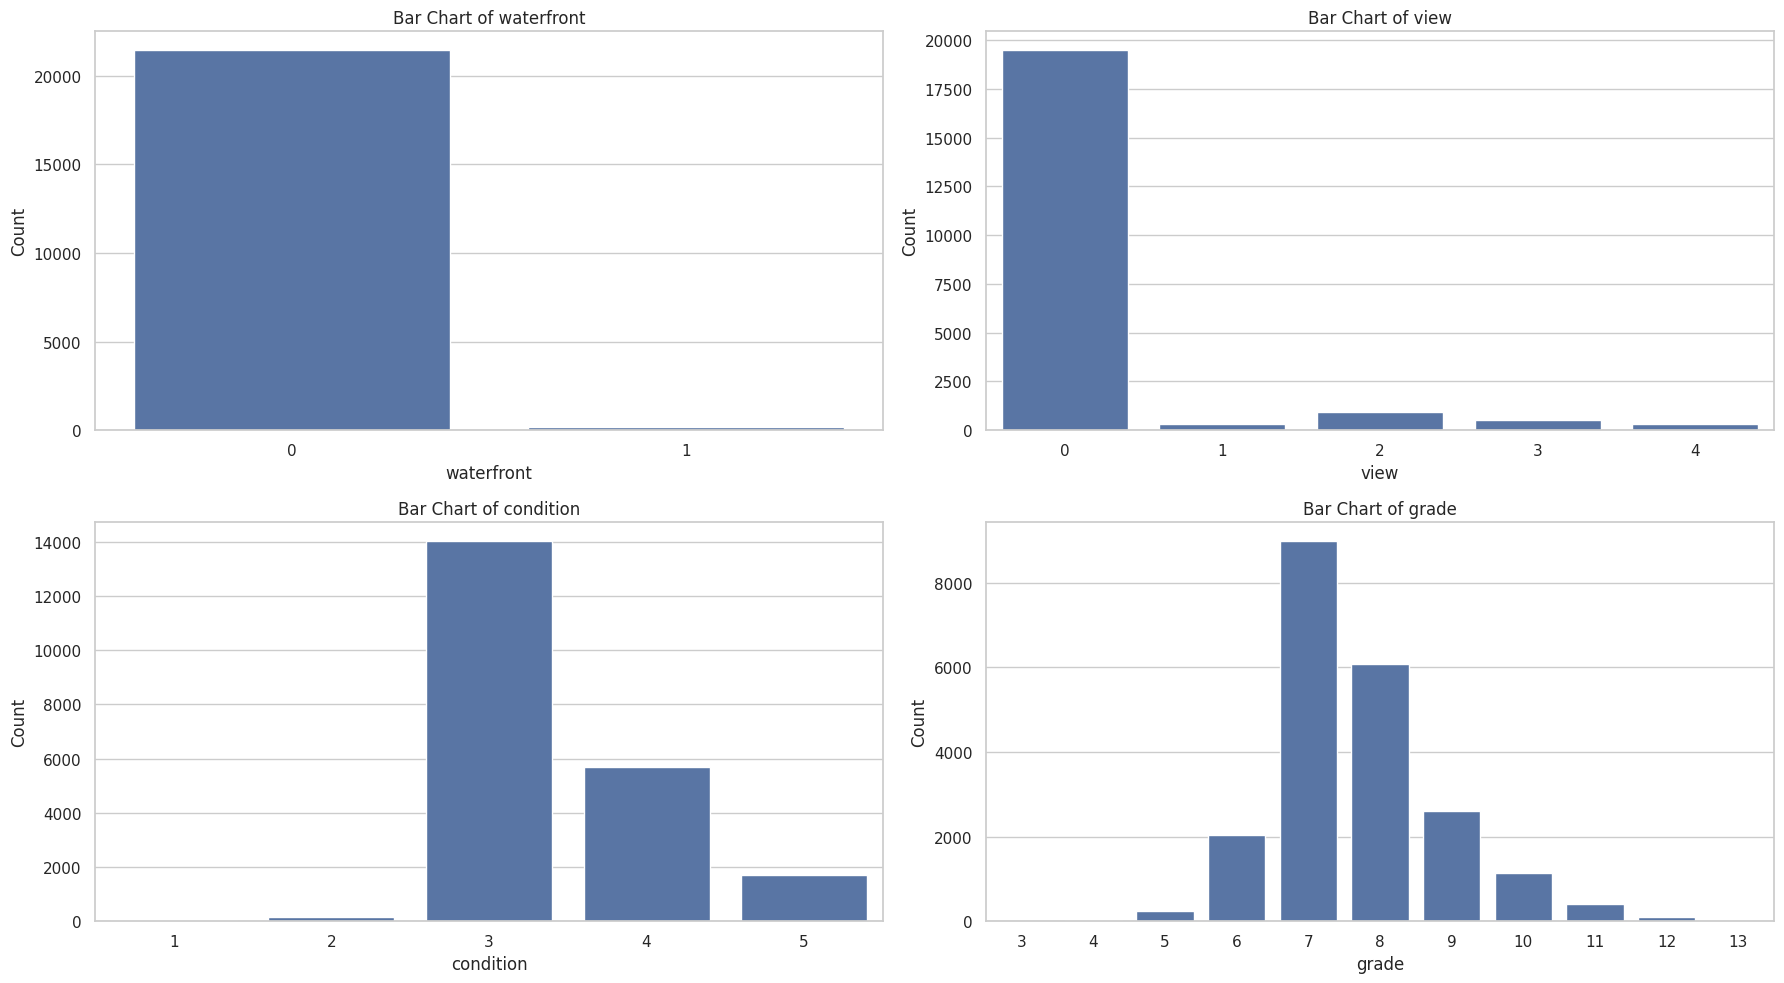

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics for the plots
sns.set(style="whitegrid")

# Define categorical variables
categorical_vars = ['waterfront', 'view', 'condition', 'grade']

# Bar charts for categorical variables
plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_vars, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[col])
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

Based on the obtained Bar Charts, the following conclusions can be drawn:

* Waterfront: Most houses do not have a waterfront view.
* View: Most houses have a view rating of 0 (no view), with fewer houses having better views.
* Condition: Most houses are in average condition (rated 3), with fewer houses in poor or excellent condition.
* Grade: Most houses have an average to above-average grade (6-8), with fewer houses at the extremes.

*  **Visualizing Continuous Variables**

We will use histograms and box plots to visualize the distribution of continuous variables.

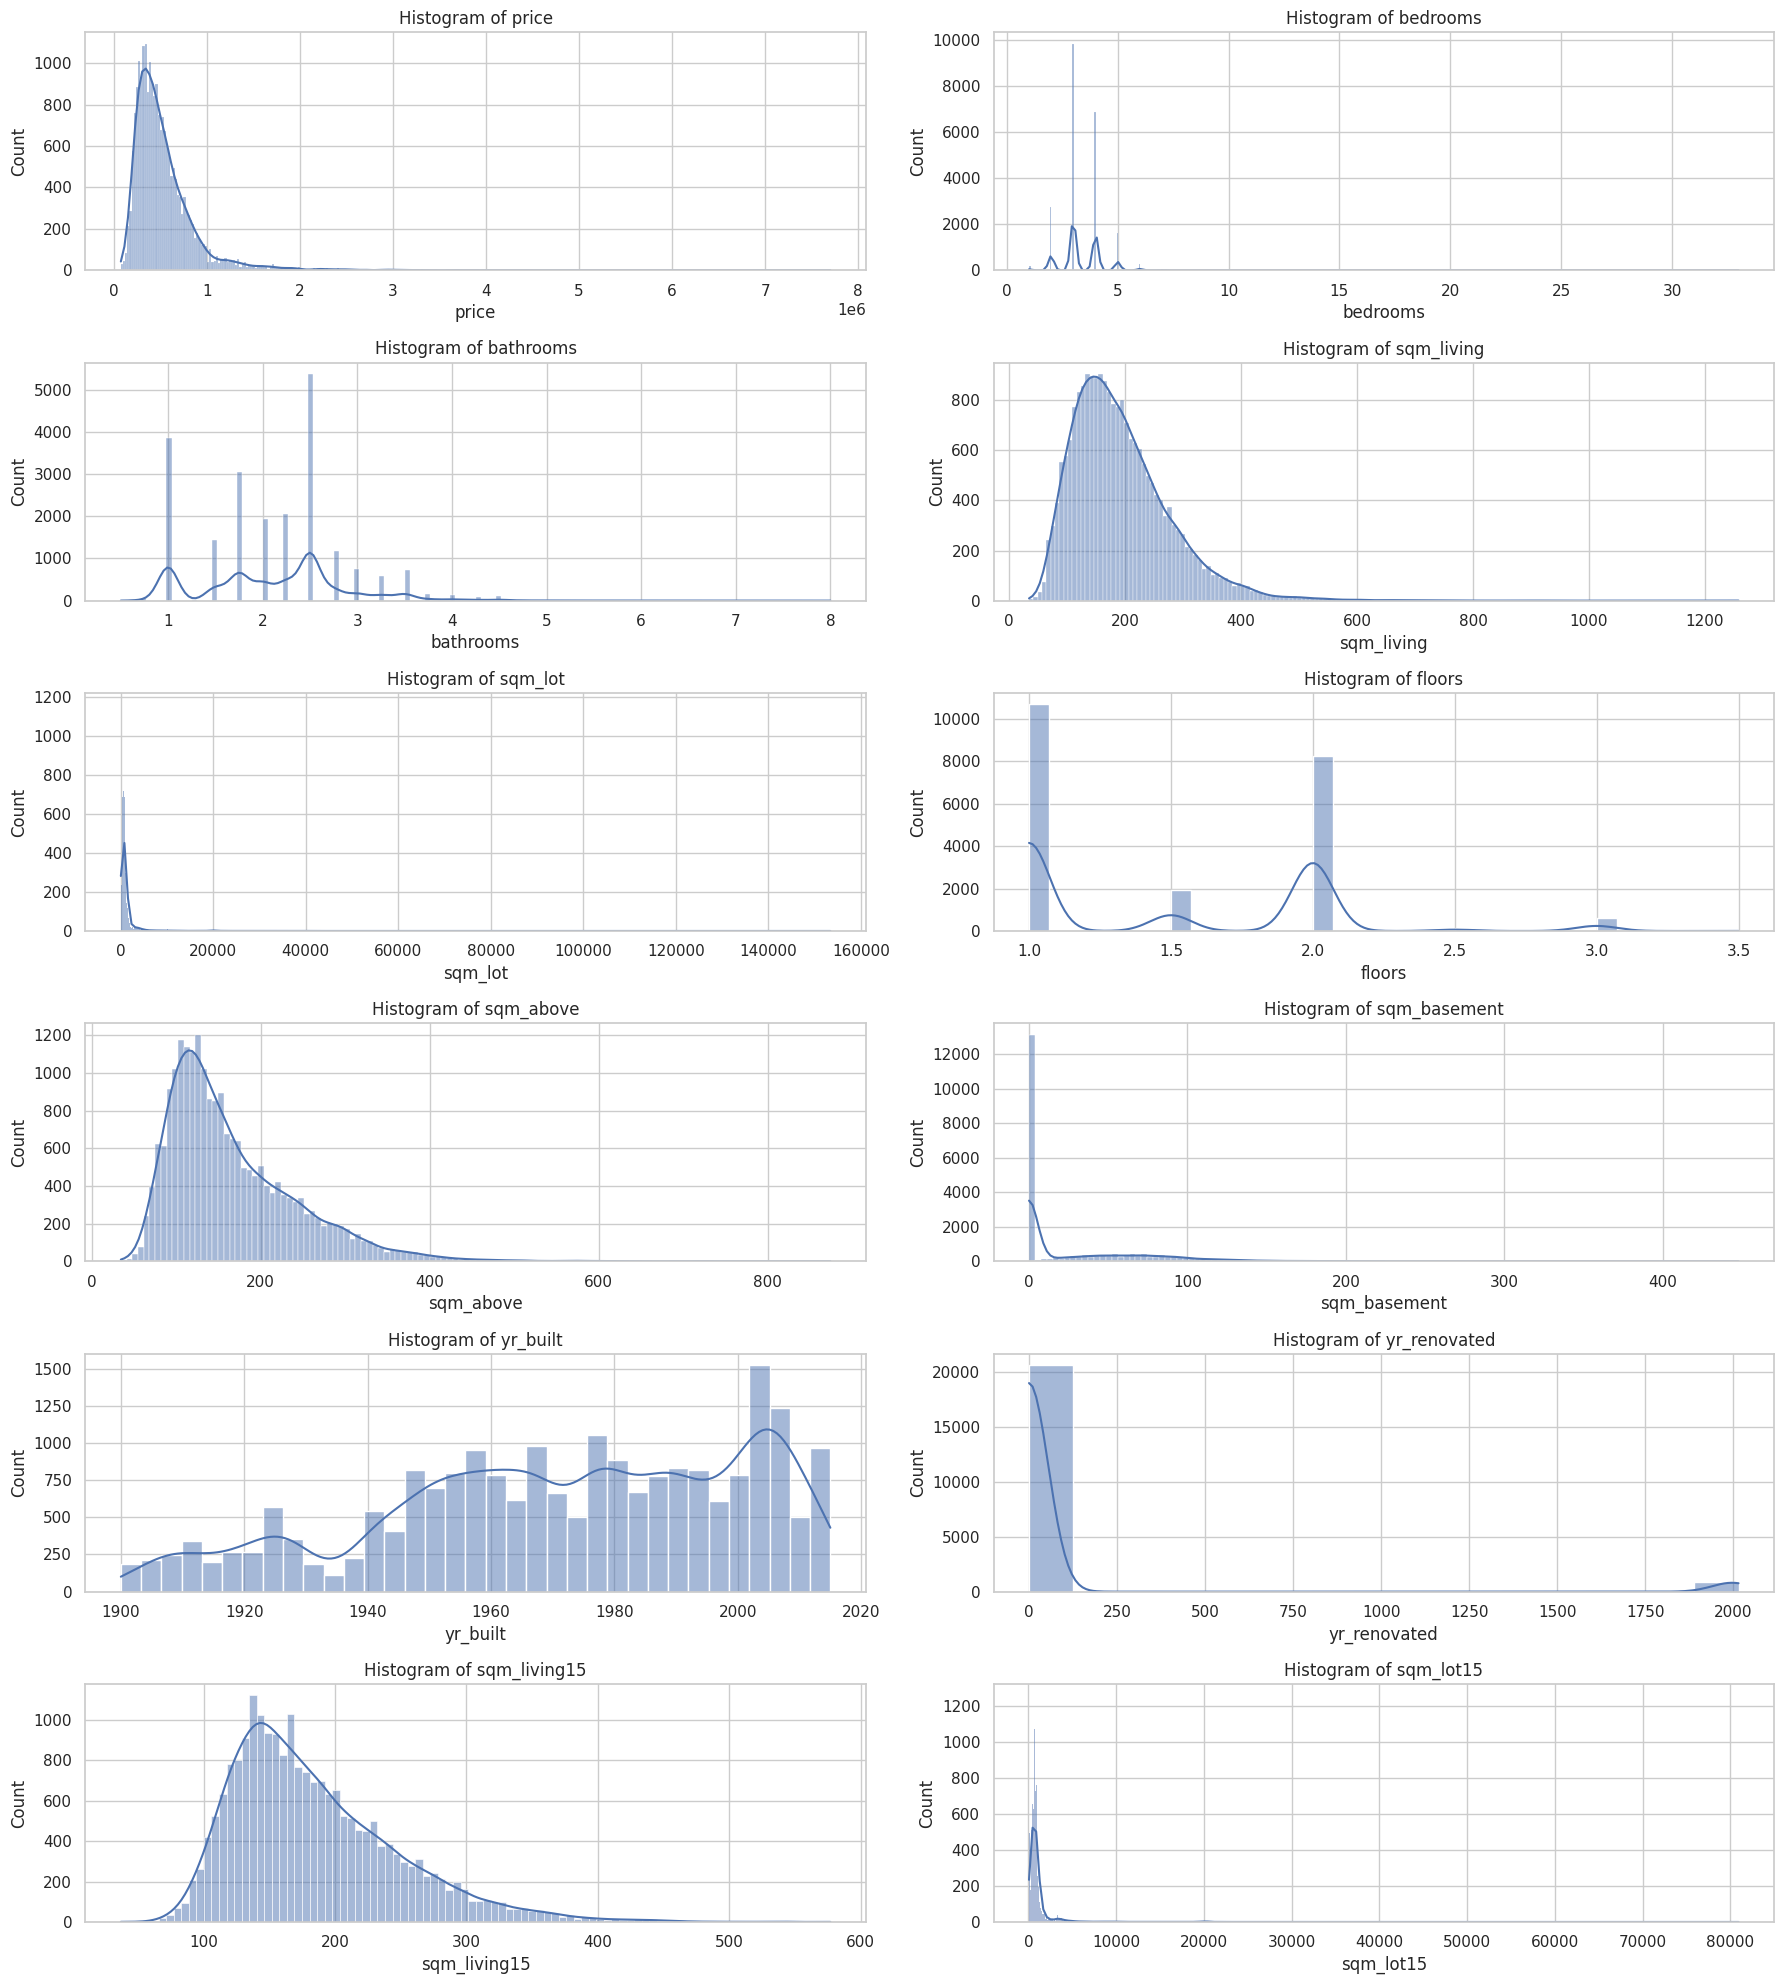

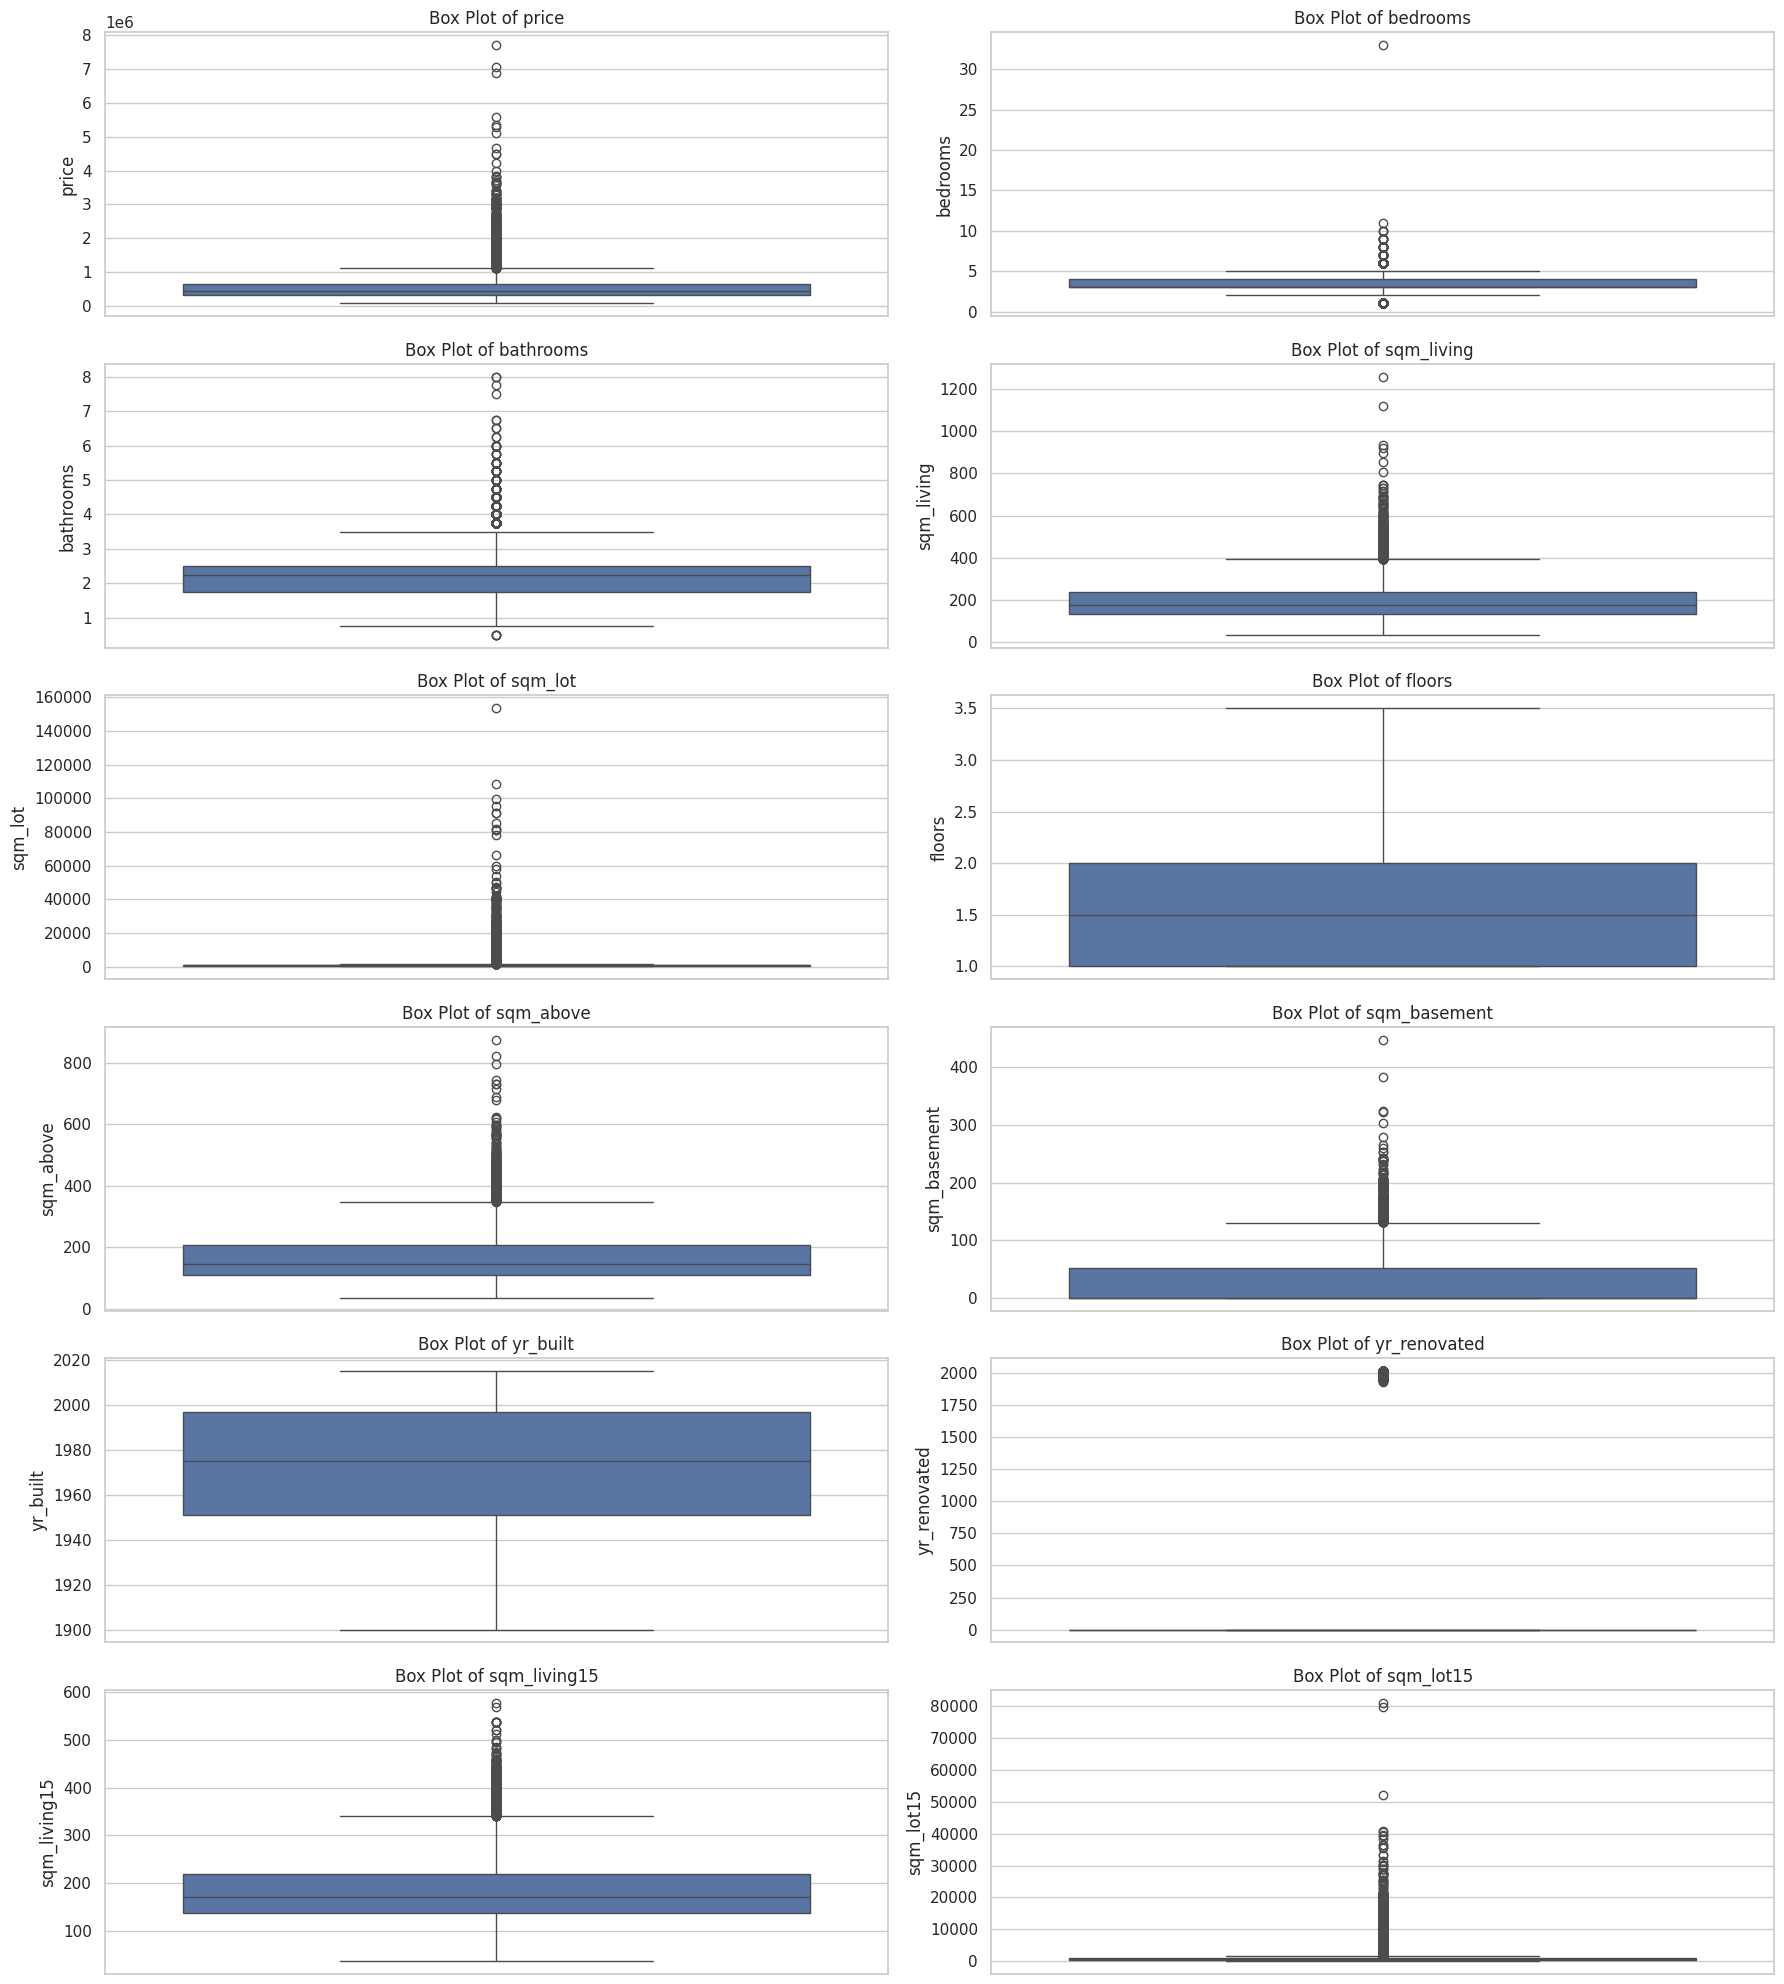

In [ ]:
# Define continuous variables
continuous_vars = ['price', 'bedrooms', 'bathrooms', 'sqm_living', 'sqm_lot', 'floors',
                   'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated',
                   'sqm_living15', 'sqm_lot15']

# Histograms for continuous variables
plt.figure(figsize=(18, 20))
for i, col in enumerate(continuous_vars, 1):
    plt.subplot(6, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

# Box plots for continuous variables
plt.figure(figsize=(18, 20))
for i, col in enumerate(continuous_vars, 1):
    plt.subplot(6, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

Based on the obtained Histograms, the following conclusions can be drawn:

* Price: Most houses are priced below $1 million, with a few very expensive houses.
* Bedrooms: Most houses have 2-4 bedrooms, with a few houses having many more bedrooms.
* Bathrooms: Most houses have 1-3 bathrooms, with fewer houses having more than 3 bathrooms.
* Living Area (sqm): Most houses have a living area below 400 sqm, with a few larger homes.
* Lot Size (sqm): Most lots are below 2,000 sqm, with some very large outliers.
* Floors: Most houses have 1 or 2 floors.
* Above Ground Area (sqm): Most houses have less than 250 sqm above ground.
* Basement Area (sqm): Many houses do not have basements, as indicated by the high count at zero.
* Year Built: Houses were built over many decades, with peaks in the mid-20th century and early 2000s.
* Year Renovated: Most houses have not been renovated; those that have were renovated in recent years.
* Living Area of Nearest 15 Neighbors (sqm): Similar distribution to the main living area.
* Lot Size of Nearest 15 Neighbors (sqm): Similar distribution to the main lot sizes.

Based on the obtained Box Plots, the following conclusions can be drawn:

* Show the spread and outliers of continuous variables.
* Highlight the median, quartiles, and any potential outliers in the data.

* **Scatter Plots for Relationships Between Variables**

Scatter plots can show relationships between pairs of continuous variables.

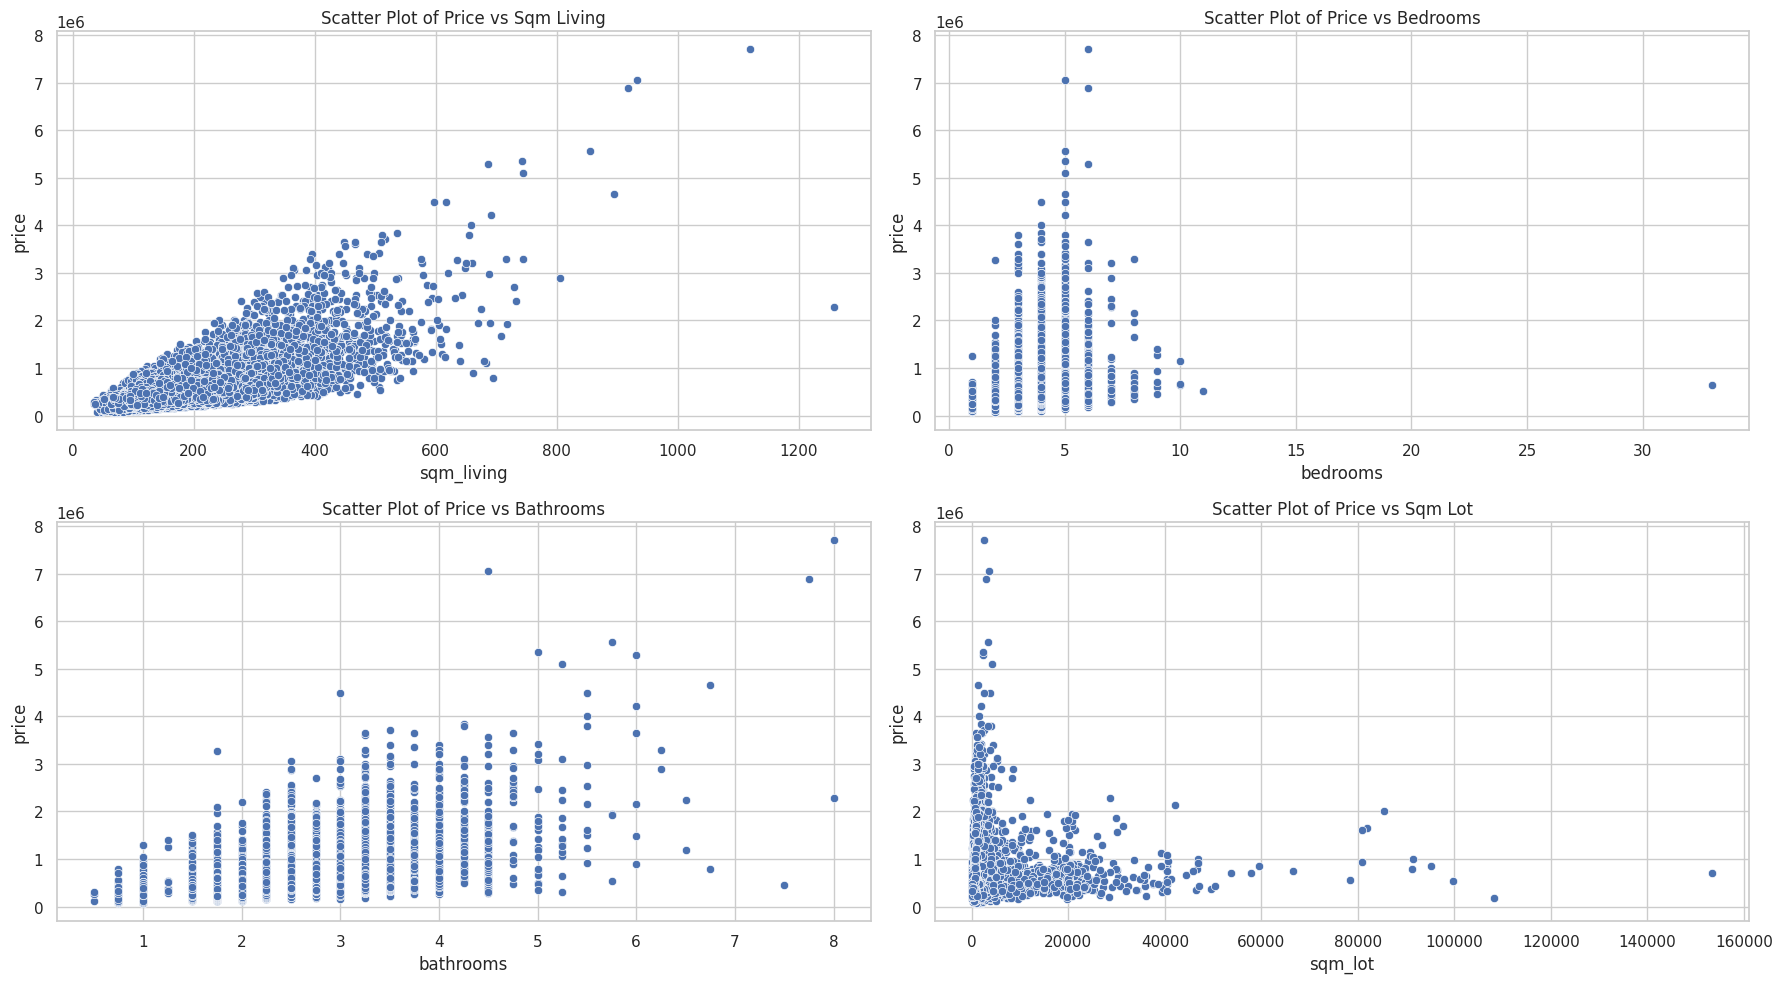

In [ ]:
# Scatter plots for selected pairs of variables
plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(x='sqm_living', y='price', data=df)
plt.title('Scatter Plot of Price vs Sqm Living')

plt.subplot(2, 2, 2)
sns.scatterplot(x='bedrooms', y='price', data=df)
plt.title('Scatter Plot of Price vs Bedrooms')

plt.subplot(2, 2, 3)
sns.scatterplot(x='bathrooms', y='price', data=df)
plt.title('Scatter Plot of Price vs Bathrooms')

plt.subplot(2, 2, 4)
sns.scatterplot(x='sqm_lot', y='price', data=df)
plt.title('Scatter Plot of Price vs Sqm Lot')

plt.tight_layout()
plt.show()

Based on the obtained Box Plots, the following conclusions can be drawn:
* Price vs Sqm Living: Positive correlation; larger living areas tend to have higher prices.
* Price vs Bedrooms: Moderate positive correlation; more bedrooms generally lead to higher prices.
* Price vs Bathrooms: Similar to bedrooms, more bathrooms correlate with higher prices.
* Price vs Sqm Lot: Positive correlation with some variance; larger lots tend to have higher prices.

* **Correlation Heatmap**

A heatmap can visualize the correlation matrix of continuous variables to show the relationships between them.

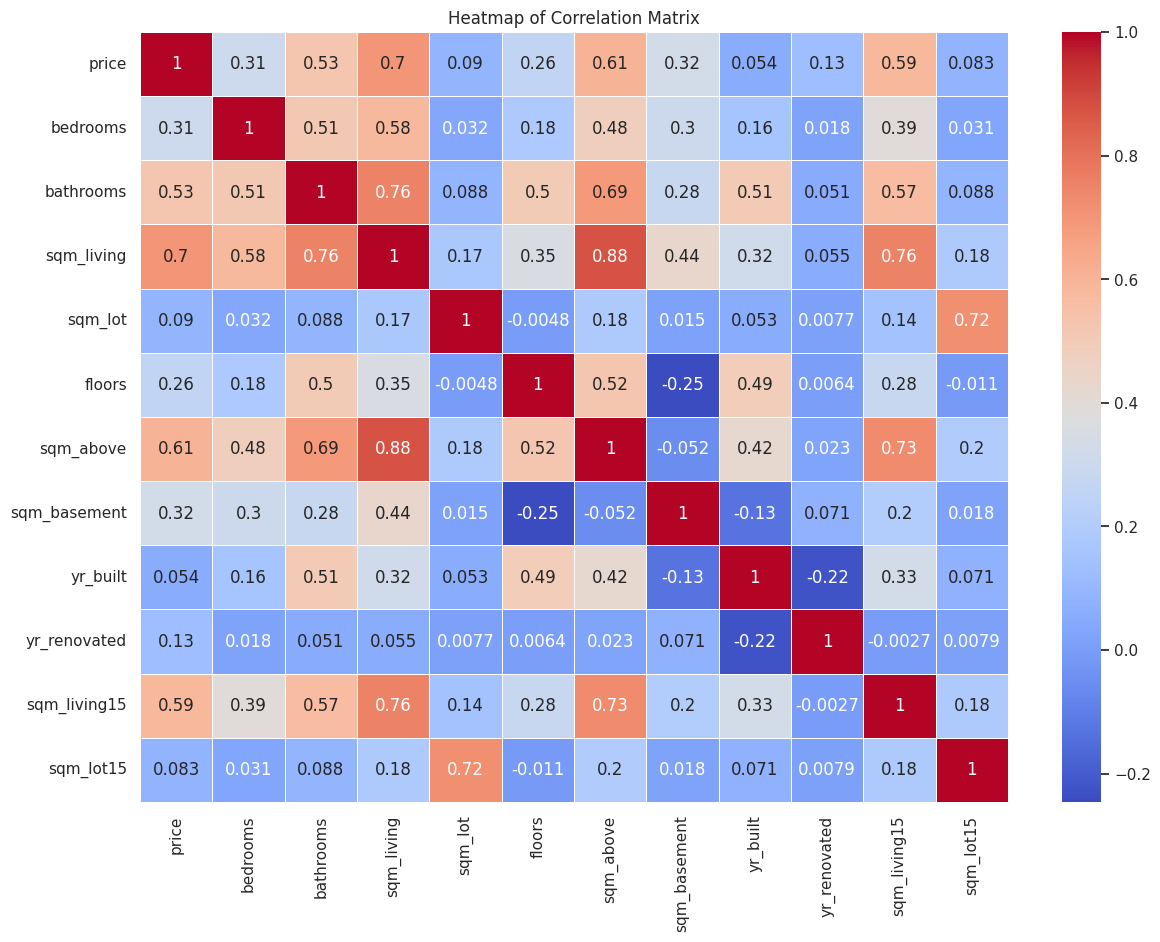

In [ ]:
# Correlation matrix
corr_matrix = df[continuous_vars].corr()

# Heatmap to visualize the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Heatmap of Correlation Matrix')
plt.show()

Based on the obtained Correlation Heatmap, the following conclusions can be drawn:

* Visualizes the correlation matrix, showing relationships between continuous variables.
* Strong positive correlations (dark red) indicate variables that move together, like sqm_living and price.
* Negative correlations (blue) show inverse relationships, though there are fewer of these in this dataset.

The analysis demonstrates the wide range of prices, sizes, and housing conditions that make up the housing market. The number of bathrooms, living area, and type of property are important price-determining elements. The majority of houses are above average to average. Although most homes cost less than a million euros, others are exceedingly costly. The majority of houses are fewer than 400 square feet in size, with 2-4 bedrooms, 1-3 bathrooms, and less than 2000 square meters of land. The majority of dwellings are fewer than 250 square meters above the ground and have one or two stories. The majority of residences took several years to construct, with the mid-1900s and early 2000s seeing the highest levels of activity. While not all of the homes have been updated, some have

## Correlation analysis
**Report variables significantly correlated with the dependent variable and specify the correlation direction.**

* Correlation with Price

The table shows the correlation coefficients between price and other variables in the dataset:

* Significant Correlations with Price

Significant correlations are identified as those with a correlation coefficient above 0.5 or below -0.5:

In [ ]:
import numpy as np

file_path = '../data/kc_house_data_eu_units.csv'
df = pd.read_csv(file_path)

# Exclude non-numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Display correlations with the dependent variable 'price'
price_corr = corr_matrix['price'].sort_values(ascending=False)
print("Correlation with Price:")
print(price_corr)

# Report variables significantly correlated with 'price'
significant_corr = price_corr[abs(price_corr) > 0.5]  # Example threshold
print("\nSignificant Correlations with Price (|corr| > 0.5):")
print(significant_corr)

Correlation with Price:
price           1.000000
sqm_living      0.701917
grade           0.667951
sqm_above       0.605368
sqm_living15    0.585241
bathrooms       0.525906
view            0.397370
sqm_basement    0.323799
bedrooms        0.308787
waterfront      0.266398
floors          0.256804
yr_renovated    0.126424
sqm_lot         0.089876
sqm_lot15       0.082845
yr_built        0.053953
condition       0.036056
id             -0.016772
Name: price, dtype: float64

Significant Correlations with Price (|corr| > 0.5):
price           1.000000
sqm_living      0.701917
grade           0.667951
sqm_above       0.605368
sqm_living15    0.585241
bathrooms       0.525906
Name: price, dtype: float64


*   sqm_living (Living Area in sqm): Shows a strong positive correlation (0.701917) with price, indicating that larger living areas are generally associated with higher prices.
*   grade: Also shows a strong positive correlation (0.667951) with price, meaning houses with higher overall grades tend to be more expensive.
*   sqm_above (Above Ground Living Area in sqm): Positively correlated with price (0.605368), suggesting that more above-ground living space leads to higher prices.
*   sqm_living15 (Living Area of 15 Nearest Neighbors in sqm): Shows a positive correlation (0.585241), indicating that houses in neighborhoods with larger living areas tend to be more expensive.
*   bathrooms: Positively correlated (0.525906), meaning more bathrooms are associated with higher house prices.

**Create Scatter Plots**

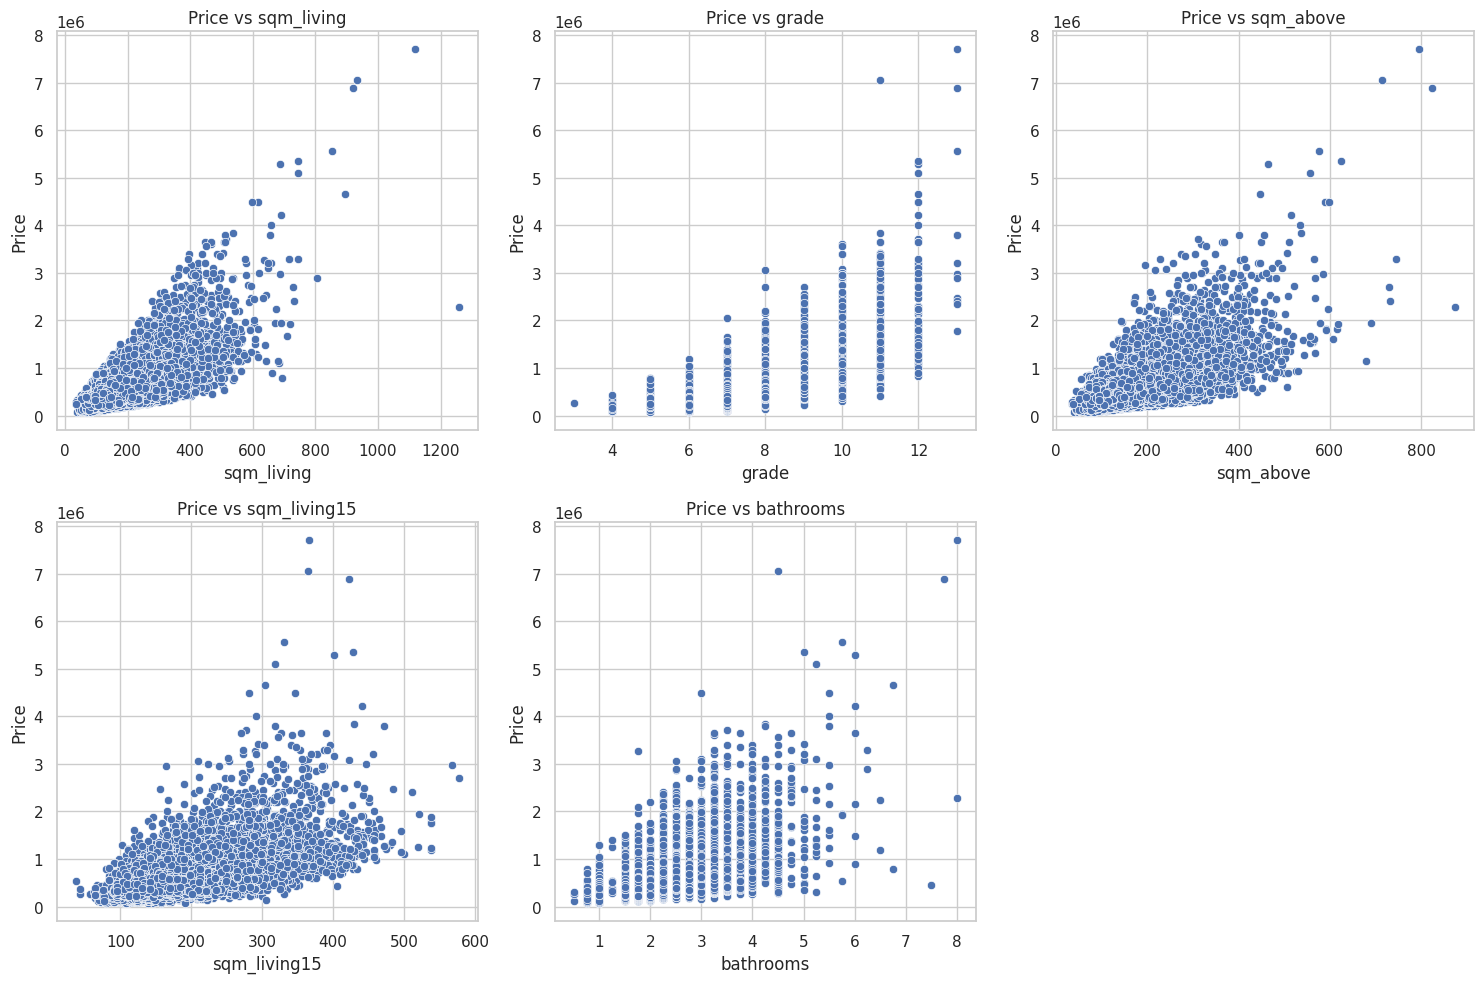

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Significant variables
significant_vars = ['sqm_living', 'grade', 'sqm_above', 'sqm_living15', 'bathrooms']

plt.figure(figsize=(15, 10))
for i, var in enumerate(significant_vars, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[var], y=df['price'])
    plt.title(f'Price vs {var}')
    plt.xlabel(var)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()

The analysis shows that several variables are positively correlated with housing prices in the data set, and are particularly visible: living area (sqm_living), overall home rating (grade), above-ground living area (sqm_above), living area of ​​15 nearest neighbors (sqm_living15) and number of bathrooms. This data shows that larger, higher-end homes with more bathrooms cost more.

**Report several most significant correlations between other variables.**

The table below lists the most significant correlations between other variables in the dataset:

In [ ]:
# Find the most significant correlations between other variables
corr_matrix_unstacked = corr_matrix.unstack()
sorted_corr = corr_matrix_unstacked.sort_values(kind="quicksort", ascending=False)
sorted_corr = sorted_corr[sorted_corr < 1]  # Exclude self-correlations
print("\nMost Significant Correlations Between Other Variables:")
print(sorted_corr.head(10))


Most Significant Correlations Between Other Variables:
sqm_above     sqm_living      0.876448
sqm_living    sqm_above       0.876448
              grade           0.762779
grade         sqm_living      0.762779
sqm_living15  sqm_living      0.756402
sqm_living    sqm_living15    0.756402
grade         sqm_above       0.756073
sqm_above     grade           0.756073
bathrooms     sqm_living      0.755758
sqm_living    bathrooms       0.755758
dtype: float64


*   sqm_above vs sqm_living: Shows a very strong positive correlation (0.876448). This indicates that houses with more above-ground living space also tend to have a larger total living area.
*   sqm_living vs grade: Shows a strong positive correlation (0.762779). This suggests that houses with a larger living area tend to have a higher grade.
*   sqm_living15 vs sqm_living: Shows a strong positive correlation (0.756402). This means that houses with a larger living area are often located in neighborhoods with larger houses.
*   grade vs sqm_above: Shows a strong positive correlation (0.756073). This indicates that houses with a higher grade also tend to have more above-ground living space.
*   bathrooms vs sqm_living: Shows a strong positive correlation (0.755758). This means that houses with more bathrooms also tend to have a larger living area.

To visualize these significant correlations, we created scatter plots for each pair of variables with the highest correlations.

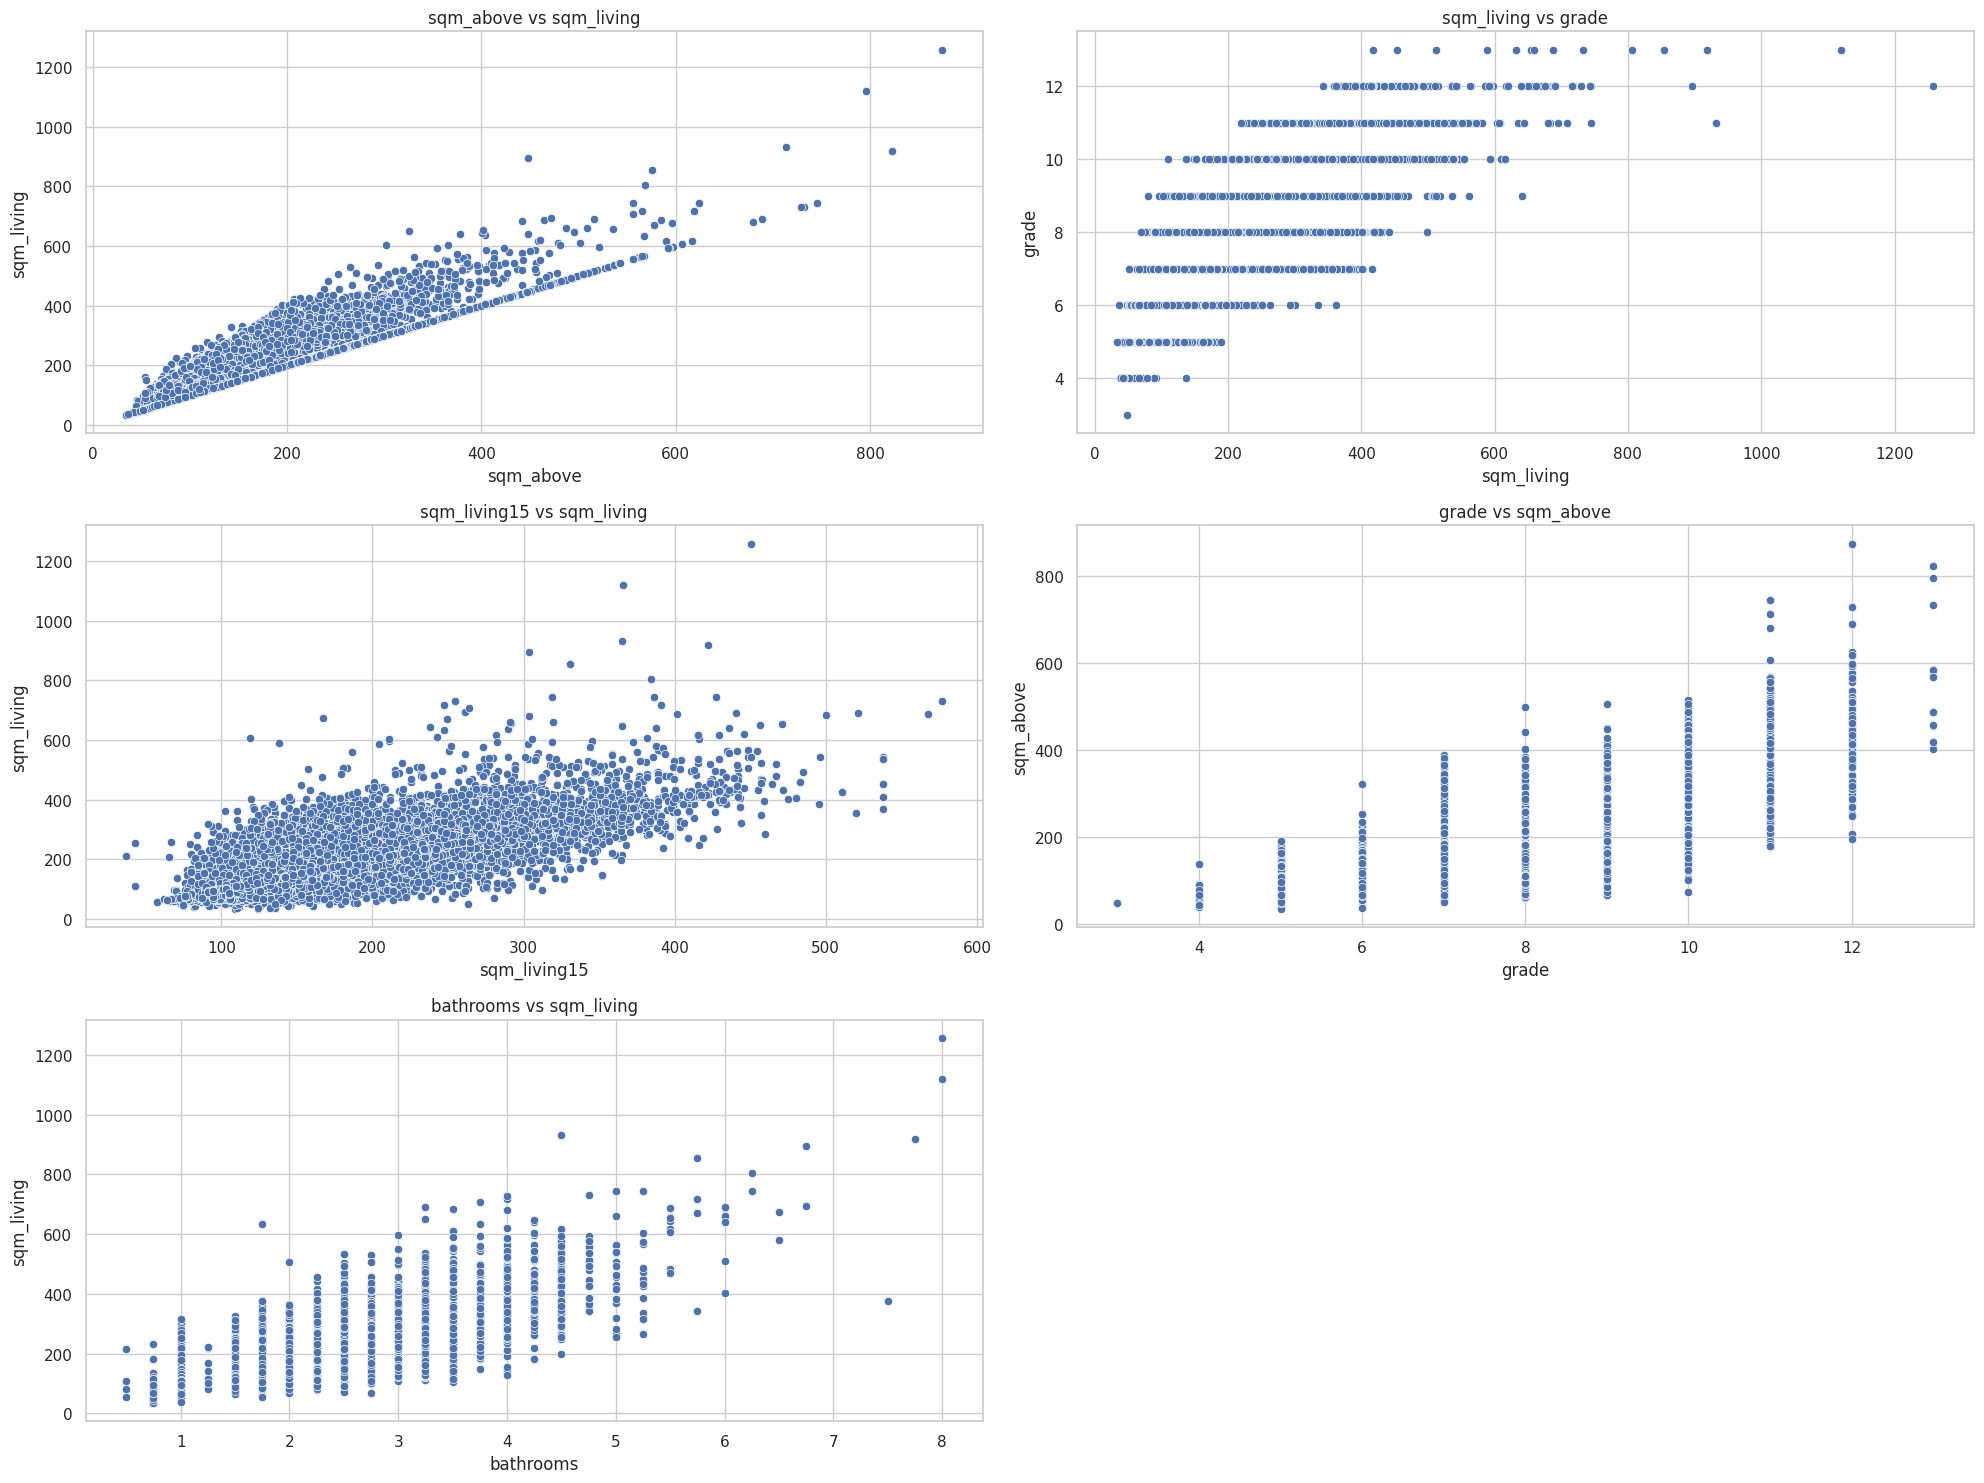

In [ ]:
# Significant variable pairs
significant_pairs = [
    ('sqm_above', 'sqm_living'),
    ('sqm_living', 'grade'),
    ('sqm_living15', 'sqm_living'),
    ('grade', 'sqm_above'),
    ('bathrooms', 'sqm_living')
]

plt.figure(figsize=(20, 15))
for i, (var1, var2) in enumerate(significant_pairs, 1):
    plt.subplot(3, 2, i)
    sns.scatterplot(x=df[var1], y=df[var2])
    plt.title(f'{var1} vs {var2}')
    plt.xlabel(var1)
    plt.ylabel(var2)

plt.tight_layout()
plt.show()

Analysis of correlations between variables shows relationships between various house attributes, namely, total living area (sqm_living), above-ground living area (sqm_above) and house class are highly correlated, indicating that larger houses with larger living area tend to be have higher grades. Additionally, the number of bathrooms and living area of ​​immediate neighbors (sqm_living15) show a strong correlation with living area, suggesting that larger homes tend to have more bathrooms and are located in neighborhoods with larger homes.

**Create Scatter Plots**

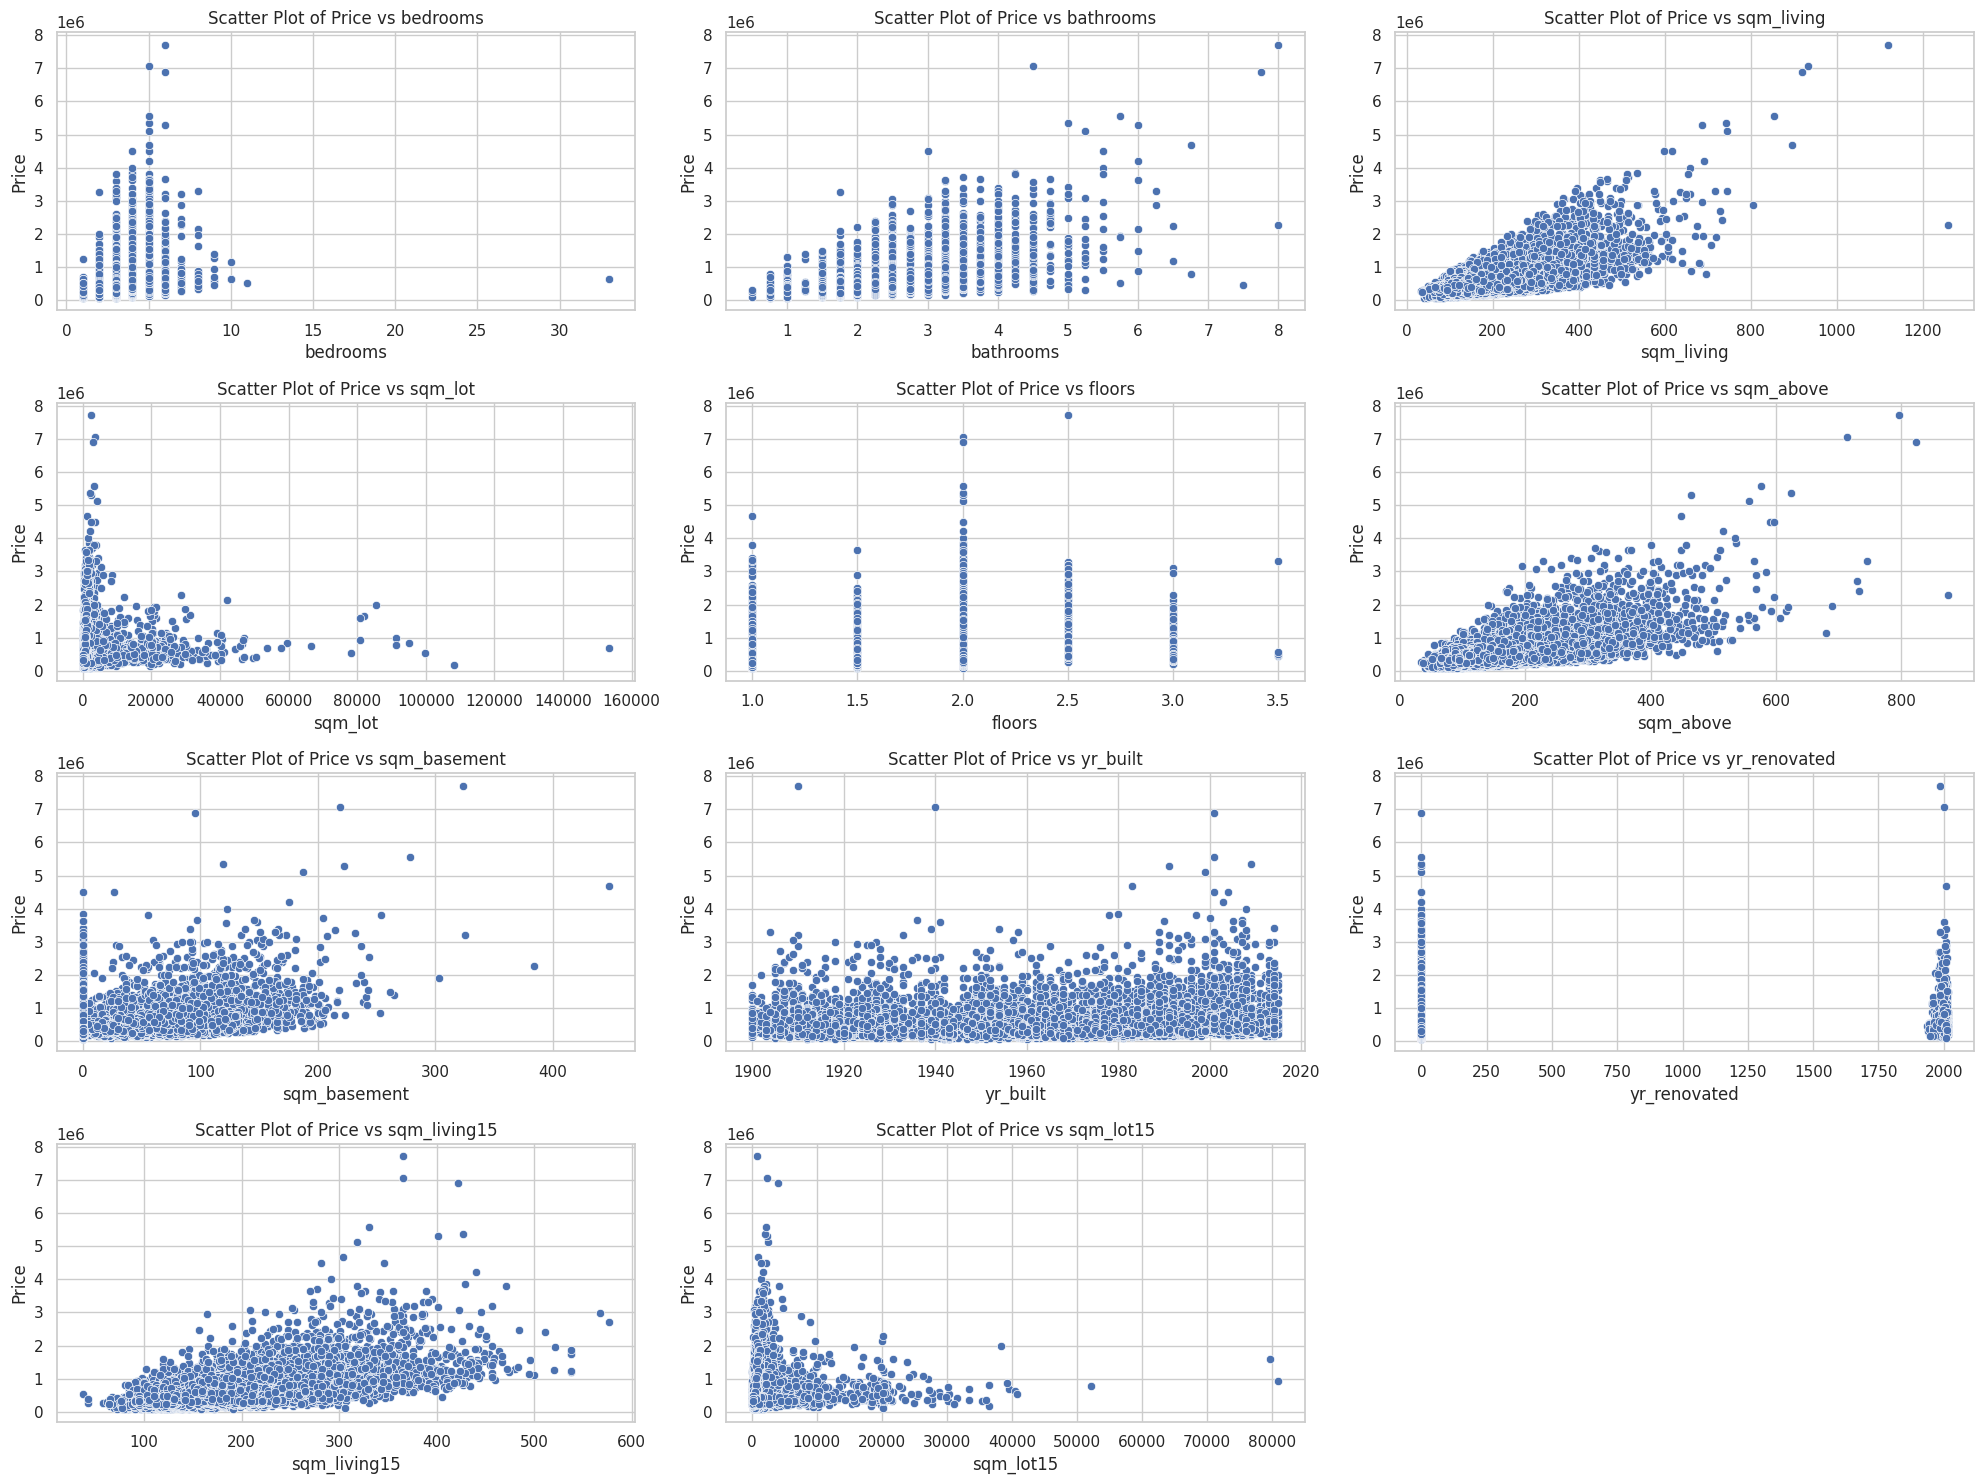

In [ ]:
# List of continuous variables (excluding the dependent variable 'price')
continuous_vars = ['bedrooms', 'bathrooms', 'sqm_living', 'sqm_lot', 'floors',
                   'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated',
                   'sqm_living15', 'sqm_lot15']

# Create scatter plots
plt.figure(figsize=(20, 15))
for i, col in enumerate(continuous_vars, 1):
    plt.subplot(4, 3, i)
    sns.scatterplot(x=df[col], y=df['price'])
    plt.title(f'Scatter Plot of Price vs {col}')
    plt.xlabel(col)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()

* **Scatter Plot of Price vs. Bedrooms:**
Shows a positive but weak relationship with price. Higher prices are seen with a moderate number of bedrooms (around 3-6).
There is a notable outlier with a very high number of bedrooms and high price.
* **Scatter Plot of Price vs. Bathrooms:**
Displays a positive correlation, where more bathrooms tend to correlate with higher prices.
Prices seem to increase steadily with the number of bathrooms up to around 4, after which the relationship becomes less clear.
* **Scatter Plot of Price vs. Sqm Living:**
Strong positive correlation, indicating that larger living areas are associated with higher prices.
This plot shows a clear linear trend.
* **Scatter Plot of Price vs. Sqm Lot:**
Weak positive correlation. While larger lots can have higher prices, there are many lower-priced houses with large lots.
* **Scatter Plot of Price vs. Floors:**
Shows some relationship, but less clear than other variables. Most houses have 1-2 floors, with higher prices scattered across these values.
* **Scatter Plot of Price vs. Sqm Above:**
Positive correlation similar to the total living area. Larger above-ground areas are associated with higher prices.
* **Scatter Plot of Price vs. Sqm Basement:**
Shows a positive but weak relationship with price. Houses with basements tend to be slightly more expensive.
* **Scatter Plot of Price vs. Yr Built:**
Weak correlation. Prices are spread across years, though newer houses might have higher prices.
* **Scatter Plot of Price vs. Yr Renovated:**
Weak but noticeable correlation. Houses renovated around 2000 show higher prices, indicating recent renovations might add value.
* **Scatter Plot of Price vs. Sqm Living15:**
Positive correlation. Houses in neighborhoods with larger living areas tend to have higher prices.
* **Scatter Plot of Price vs. Sqm Lot15:**
Weak positive correlation. Larger neighboring lots can correspond to higher prices, but the relationship is less clear.

The analysis discovered that the best indicators of home values are living area, grade, and bathrooms. Higher grade residences are more expensive, and larger living areas also result in higher property prices. The relationship between above-ground living area and total living area is substantial, and it also predicts pricing. A house with more bathrooms usually has more value. Greater living areas in a neighbourhood are more expensive. Although they have less connections, other variables including the number of floors, year of construction, and renovations can still be predictive.

**Estimate the Linear Regression Model**

Regression model results are provided below. The dependent variable is the house price, and the model includes various independent variables such as the number of bedrooms, bathrooms, living area (sqm_living), and other features.

* **R-squared: 0.654**
Indicates that approximately 65.4% of the variance in house prices can be explained by the independent variables in the model.
* **Adjusted R-squared: 0.654**
Adjusted for the number of predictors in the model, which remains the same, indicating a good fit.
* **F-statistic: 2917**
Indicates that the overall model is statistically significant.
* **Prob (F-statistic): 0.00**

P-value indicating the model is highly significant.

**Coefficients and Significance**

The table below summarizes the coefficients, standard errors, t-values, and p-values for each predictor in the model:

*   const: The intercept of the regression model. A high positive value indicates a high baseline house price when all predictors are zero.
*   bedrooms: The coefficient is negative, indicating that an increase in the number of bedrooms is associated with a decrease in house price, when other factors are held constant.
*   bathrooms: Positive and significant, indicating that more bathrooms are associated with higher house prices.
*   sqm_living: Highly significant and positive, showing that larger living areas lead to higher prices.
*   sqm_lot: Not significant, indicating that the lot size does not have a clear linear relationship with price in this model.
*   floors: Positive and significant, indicating more floors are associated with higher prices.
*   waterfront: Strong positive impact on price, suggesting houses with waterfront views are much more expensive.
*   view: Positive and significant, indicating that better views increase house prices.
*   condition: Positive and significant, suggesting that better condition increases house prices.
*   grade: Highly significant, showing that higher grade significantly increases house prices.
*   sqm_above: Positive and significant, indicating that more above-ground living space increases house prices.
*   sqm_basement: Positive and significant, indicating that larger basements increase house prices.
*   yr_built: Negative and significant, suggesting older houses are generally less expensive.
*   yr_renovated: Positive and significant, indicating that houses renovated more recently are more expensive.
*   sqm_living15: Positive and significant, indicating that houses in neighborhoods with larger living areas are more expensive.
*   sqm_lot15: Negative and significant, indicating that houses in neighborhoods with larger lot sizes tend to be less expensive, possibly due to being in less dense or desirable areas.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns

model_df = pd.read_csv('../data/kc_house_data_eu_units.csv')
model_df['date'] = pd.to_datetime(model_df['date'], errors='coerce')

Y = model_df['price']
X = model_df.drop(columns=['price', 'id', 'date']).apply(pd.to_numeric, errors='coerce')
valid_rows = X.notna().all(axis=1) & Y.notna()
X = X.loc[valid_rows]
Y = Y.loc[valid_rows]
model_df = model_df.loc[valid_rows].copy()

X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
print(model.summary())

id                int64
date              int64
price             int64
bedrooms          int64
bathrooms       float64
sqm_living      float64
sqm_lot         float64
floors          float64
waterfront        int64
view              int64
condition         int64
grade             int64
sqm_above       float64
sqm_basement    float64
yr_built          int64
yr_renovated      int64
sqm_living15    float64
sqm_lot15       float64
dtype: object
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     2917.
Date:                Fri, 07 Jun 2024   Prob (F-statistic):               0.00
Time:                        19:10:38   Log-Likelihood:            -2.9592e+05
No. Observations:               21597   AIC:                         5.919e+05
D


Regression analysis has identified several factors that significantly influence housing prices. More living space, higher grades and more bathrooms are associated with higher prices. Homes with waterfront views and general views cost more. The number of bedrooms is negatively associated with price, possibly due to multicollinearity with other variables. Older homes are cheaper, but recent renovations increase their value. Neighborhood characteristics, such as living space, also play an important role in determining home prices. An R-squared value of 0.654 indicates a good fit, but further refinement and variable selection or transformation may be required.

**Model goodness-of-fit**

In [ ]:
# Extract and print model goodness-of-fit, significance, and direction of significant variables
print("\nModel Goodness-of-Fit:")
print(f"R-squared: {model.rsquared}")
print(f"Adjusted R-squared: {model.rsquared_adj}")


Model Goodness-of-Fit:
R-squared: 0.6542520981618738
Adjusted R-squared: 0.6540278153972675


The model's R-squared and adjusted R-squared values indicate a good fit with the data, with a high R-squared value indicating that the chosen predictors effectively explain the variability in house prices. The minimal difference between the R-squared and adjusted R-squared values confirms that the model is appropriately specified with a suitable number of predictors, indicating that the model should perform well in predicting house prices based on the included features.

**Significance of model coefficients**

The following variables have been identified as important in predicting house prices. The direction (positive or negative) indicates whether an increase in a variable is associated with changes in house prices.

In [ ]:
print("\nSignificant Model Coefficients:")
significant_vars = model.pvalues[model.pvalues < 0.05].index
print(f"Significant Variables: {significant_vars}")


Significant Model Coefficients:
Significant Variables: Index(['const', 'bedrooms', 'bathrooms', 'sqm_living', 'floors', 'waterfront',
       'view', 'condition', 'grade', 'sqm_above', 'sqm_basement', 'yr_built',
       'yr_renovated', 'sqm_living15', 'sqm_lot15'],
      dtype='object')


**Direction of significant variables**

*   const: 6,206,135.91 (positive)
•	The house price when all predictors are at zero. This high positive value serves as the intercept.
*   bedrooms: -39,188.13 (negative)
•	Each additional bedroom is associated with a decrease in house price, suggesting that, when controlling for other factors, additional bedrooms might not add significant value.
*   bathrooms: 45,945.39 (positive)
•	Each additional bathroom is associated with an increase in house price, indicating that more bathrooms add significant value.
*   sqm_living: 1,173.61 (positive)
•	Each additional square meter of living space is associated with an increase in house price, showing a strong positive impact.
*   floors: 26,595.05 (positive)
•	Each additional floor is associated with an increase in house price, suggesting multi-story homes are valued higher.
*   waterfront: 579,486.50 (positive)
•	Houses with waterfront views are significantly more expensive, highlighting the premium for such locations.
*   view: 43,125.14 (positive)
•	Better views contribute positively to house prices.
*   condition: 19,921.90 (positive)
•	Better condition homes have higher prices.
*   grade: 120,878.16 (positive)
•	Higher graded homes are significantly more expensive, indicating overall quality and finish add value.
*   sqm_above: 554.26 (positive)
•	Each additional square meter above ground contributes positively to house prices.
*   sqm_basement: 619.35 (positive)
•	Each additional square meter of basement space increases house prices, though slightly less than above-ground space.
*   yr_built: -3,580.03 (negative)
•	Newer homes are more expensive. Each additional year since the house was built is associated with a decrease in price.
*   yr_renovated: 10.15 (positive)
•	Recently renovated homes add slightly to the house price.
*   sqm_living15: 261.00 (positive)
•	The average living space of the 15 nearest neighbors positively impacts house prices, indicating neighborhood characteristics matter.
*   sqm_lot15: -6.04 (negative)
•	Larger lot sizes of the 15 nearest neighbors are associated with a slight decrease in house price, possibly indicating less desirable, less dense areas.


In [ ]:
for var in significant_vars:
    coef = model.params[var]
    direction = "positive" if coef > 0 else "negative"
    print(f"{var}: {coef} ({direction})")

const: 6206135.908035906 (positive)
bedrooms: -39188.13499014158 (negative)
bathrooms: 45945.389906399134 (positive)
sqm_living: 1173.6099433626678 (positive)
floors: 26595.051662639737 (positive)
waterfront: 579486.5023324761 (positive)
view: 43125.143717917395 (positive)
condition: 19921.896027748786 (positive)
grade: 120878.15755790919 (positive)
sqm_above: 554.2589233659432 (positive)
sqm_basement: 619.351015075237 (positive)
yr_built: -3580.0297036914753 (negative)
yr_renovated: 10.148801309264009 (positive)
sqm_living15: 261.00159521297365 (positive)
sqm_lot15: -6.037195379274809 (negative)


The analysis of model coefficients reveals that factors such as larger living areas, higher grades, bathrooms, additional floors, waterfront properties, good views, better condition, and recent renovations significantly increase house prices. The living space of nearby homes also contributes positively. However, the number of bedrooms has a negative association, possibly due to multicollinearity or saturation effects. Older houses are less expensive, and larger lot sizes of neighboring properties are slightly negatively correlated with house prices.

## Construct Histogram of Residuals

**Histogram of Residuals (Initial Model)**

The first histogram shows the distribution of residuals from the initial regression model:

Shape: The histogram is highly peaked and narrow, indicating that most residuals are close to zero.
Skewness: There is some right skewness, with a few large positive residuals extending to the right.
Kurtosis: The histogram shows a high peak and long tails, suggesting leptokurtic distribution.
Implication: The presence of skewness and kurtosis indicates potential issues with normality assumptions. These characteristics suggest the presence of outliers and possibly some model specification issues.

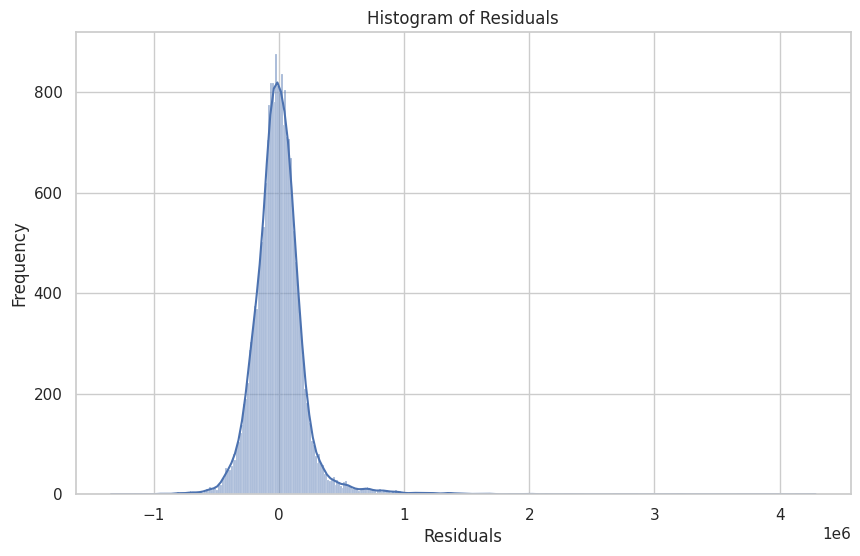

The histogram of residuals should ideally be normally distributed, centered around zero. Deviations from this pattern may indicate issues with model fit.


In [ ]:
# Calculate residuals
residuals = model.resid

# Construct histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

print("The histogram of residuals should ideally be normally distributed, centered around zero. Deviations from this pattern may indicate issues with model fit.")

**Histogram of Residuals (Cleaned Model)**

The second histogram shows the distribution of residuals after cleaning the data:

Shape: This histogram is more bell-shaped compared to the initial model's residuals, indicating better compliance with normality.
Spread: The residuals are more spread out, reflecting the removal of extreme outliers which can affect the residual distribution.
Skewness: There is less skewness compared to the initial model's residuals.
Kurtosis: The peak is less pronounced, indicating a reduction in kurtosis and a more normal distribution.
Implication: The cleaned model's residuals suggest a better fit, with fewer outliers and a more normal distribution. This indicates improved model accuracy and reliability.

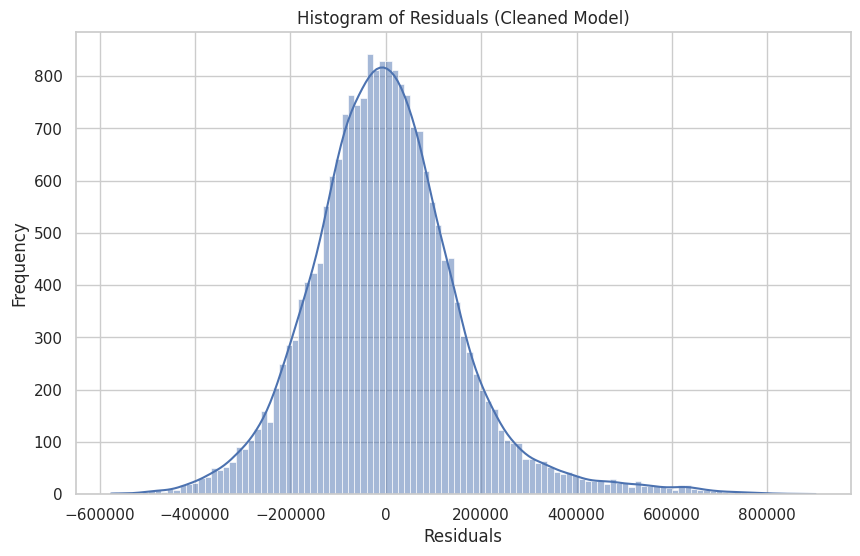

In [ ]:
import seaborn as sns
# Calculate residuals of the cleaned model
cleaned_residuals = model_cleaned.resid

# Construct histogram of residuals for the cleaned model
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_residuals, kde=True)
plt.title('Histogram of Residuals (Cleaned Model)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

The residuals from the original model showed high kurtosis and skewness, indicating potential outliers and deviations from normality. After removing outliers, the residuals showed a bell-shaped distribution, indicating a better-fitting model with more accurate predictions. Decreases in skewness and kurtosis indicate better model assumptions, leading to more reliable conclusions.

## Scatter Plot of Residuals

**Residuals vs. Fitted Values (Initial Model)**

Shape and Spread: The residuals fan out as the fitted values increase, indicating heteroscedasticity. This pattern suggests that the variance of the residuals is not constant across all levels of the fitted values.
Outliers: There are noticeable outliers, especially for higher fitted values, indicating that the model might not be capturing some aspects of the data accurately.
Implication: The presence of heteroscedasticity suggests that the model assumptions may be violated, and further transformations or adjustments might be needed to improve model performance and reliability.


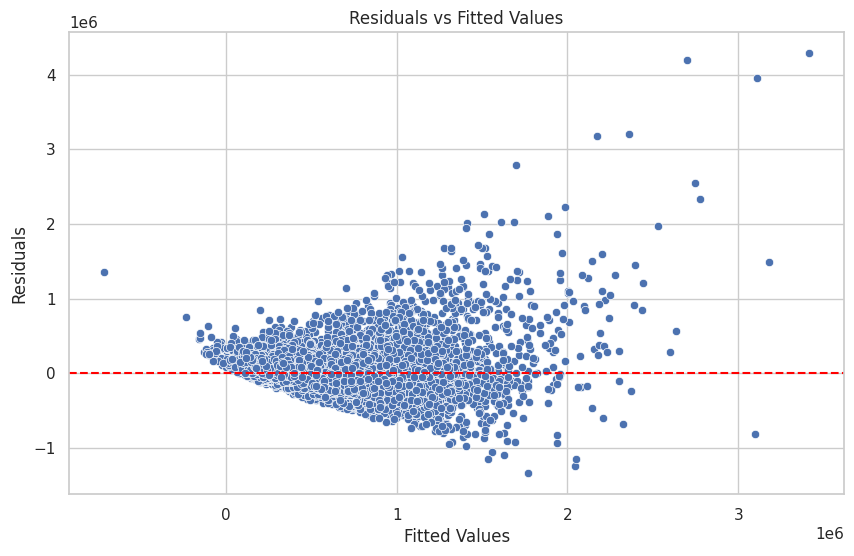

A random scatter of residuals around zero indicates a good fit. Patterns or trends in this plot may suggest the need to exclude outliers or improve the model.


In [ ]:
# Scatter plot of residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=model.fittedvalues, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

print("A random scatter of residuals around zero indicates a good fit. Patterns or trends in this plot may suggest the need to exclude outliers or improve the model.")

**Residuals vs. Fitted Values (Cleaned Model)**

Shape and Spread: The residuals are more evenly distributed around the red dashed line (zero residuals), indicating a better fit compared to the initial model. However, some heteroscedasticity still exists but to a lesser extent.
Outliers: There are fewer extreme outliers, showing that cleaning the data has helped to reduce their impact.
Implication: The cleaned model shows improved residual distribution, suggesting better compliance with model assumptions. Although some heteroscedasticity remains, the overall fit is better, indicating a more reliable model.

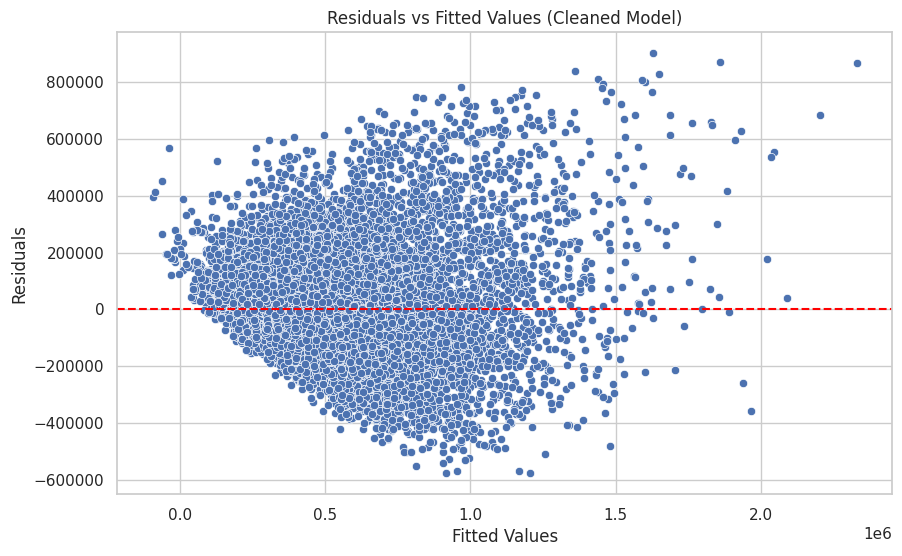

In [ ]:
# Scatter plot of residuals for the cleaned model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=model_cleaned.fittedvalues, y=cleaned_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values (Cleaned Model)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

The residuals vs. fitted values plot of the original model shows a variability pattern, indicating prediction biases and inefficiencies. The residuals show better model fit after data cleaning because they are more symmetrical around zero. The consistent variance of the residuals and the decrease in outliers point to a more reliable and trusted model.

## Exclude Outliers and Refit Model:

After excluding the outliers, the regression model was refitted. The results show an improvement in model fit as indicated by the following key statistics:

*  **Model Goodness-of-Fit**
 * 	R-squared: 0.688
This indicates that approximately 68.8% of the variance in house prices can be explained by the independent variables included in the model, an improvement from the previous 65.4%.
 * 	Adjusted R-squared: 0.688
The adjusted R-squared also stands at 0.688, confirming the improvement in model fit after outlier exclusion.
*  **Key Statistics**
 * 	F-statistic: 3350
Indicates that the overall model is statistically significant.
 * 	Prob (F-statistic): 0.00
The p-value indicates that the model is highly significant.

*  **Significant Variables and Coefficients**
The table below summarizes the coefficients, standard errors, t-values, and p-values for each predictor in the model:
*   const: The intercept, significantly positive, indicating a high baseline house price.
*   bedrooms: Negative coefficient, indicating that each additional bedroom slightly decreases the house price, possibly due to multicollinearity with other space-related variables.
*   bathrooms: Positive coefficient, indicating that more bathrooms add significant value.
*   sqm_living: Strong positive impact, indicating that larger living areas significantly increase house prices.
*   sqm_lot: Positive but small effect, indicating larger lots slightly increase prices.
*   floors: Positive and significant, indicating more floors increase house prices.
*   waterfront: Strong positive impact, indicating houses with waterfront views are much more expensive.
*   view: Positive impact, indicating better views increase house prices.
*   condition: Positive, indicating better condition increases house prices.
*   grade: Strong positive impact, indicating higher grades significantly increase house prices.
*   sqm_above: Positive, indicating more above-ground living space increases house prices.
*   sqm_basement: Positive, indicating larger basements increase house prices.
*   yr_built: Negative, indicating newer houses are more expensive.
*   yr_renovated: Positive, indicating recent renovations add value.
*   sqm_living15: Positive, indicating houses in neighborhoods with larger living areas are more expensive.
*   sqm_lot15: Negative, indicating larger lot sizes of neighboring properties slightly decrease house prices.

In [ ]:
# Identify outliers (example criterion: residuals outside 3 standard deviations)
outliers = abs(residuals) > (3 * np.std(residuals))
df_cleaned = model_df[~outliers]

# Refit model with cleaned data
Y_cleaned = df_cleaned['price']
X_cleaned = df_cleaned.drop(columns=['price', 'id', 'date'])
X_cleaned = sm.add_constant(X_cleaned)

model_cleaned = sm.OLS(Y_cleaned, X_cleaned).fit()

# Report cleaned model summary
print(model_cleaned.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     3350.
Date:                Fri, 07 Jun 2024   Prob (F-statistic):               0.00
Time:                        19:11:32   Log-Likelihood:            -2.8490e+05
No. Observations:               21263   AIC:                         5.698e+05
Df Residuals:                   21248   BIC:                         5.699e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.516e+06   1.04e+05     53.159   

Significant problems with the original model were possible multicollinearity, outliers, and variability. With fewer outliers and less heteroscedasticity, the cleaned model performed better and could forecast home prices more accurately. Scatter plots of residuals were used to find outliers and determine which ones were to be excluded. With greater R-squared and adjusted R-squared values, the cleaned model has higher levels of reliability and consistency.

## Stepwise Elimination

Stepwise elimination is a regression model fitting technique in which independent variables are added or removed one at a time depending on their statistical significance. We added the variables listed below because they are the most important predictors of home prices. The model becomes more accurate and easier to understand, providing reliable predictions based on the most important characteristics of homes and their surroundings.

**Significant Variables and Coefficients:**

*   const: The intercept, significantly positive, indicating a high baseline house price.
*   sqm_above: Positive and significant, indicating that more above-ground living space increases house prices.
*   waterfront: Strong positive impact, indicating houses with waterfront views are significantly more expensive.
*   sqm_living15: Positive, indicating houses in neighborhoods with larger living areas are more expensive.
*   grade: Strong positive impact, indicating higher grades significantly increase house prices.
*   sqm_living: Strong positive impact, indicating that larger living areas significantly increase house prices.
*   yr_built: Negative, indicating newer houses are more expensive.
*   sqm_basement: Positive, indicating larger basements increase house prices.
*   view: Positive, indicating better views increase house prices.
*   bedrooms: Negative, indicating that each additional bedroom slightly decreases house prices, potentially due to multicollinearity.
*   bathrooms: Positive, indicating that more bathrooms add significant value.
*   sqm_lot15: Negative, indicating larger lot sizes of neighboring properties slightly decrease house prices.
*   condition: Positive, indicating better condition increases house prices.
*   floors: Positive and significant, indicating more floors increase house prices.
*   yr_renovated: Positive, indicating recent renovations add value.

In [ ]:
# Stepwise selection function
def stepwise_selection(X, y, initial_list=[], threshold_in=0.01, threshold_out=0.05, verbose=True):
    included = list(initial_list)
    while True:
        changed = False
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print('Add {:30} with p-value {:.6}'.format(best_feature, best_pval))
        # backward step
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()  # null if pvalues is empty
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

# Run stepwise selection
resulting_features = stepwise_selection(X, Y)

print('Resulting features:')
print(resulting_features)

# Remove 'const' if it is included in the resulting features
if 'const' in resulting_features:
    resulting_features.remove('const')

# Fit the final model with selected features
X_final = sm.add_constant(model_df[resulting_features])
model_final = sm.OLS(Y, X_final).fit()

# Report final model summary
print(model_final.summary())


Add bathrooms                      with p-value 0.0
Add grade                          with p-value 0.0
Add sqm_basement                   with p-value 0.0
Add waterfront                     with p-value 0.0
Add const                          with p-value 0.0
Add yr_built                       with p-value 0.0
Add sqm_living                     with p-value 0.0
Drop sqm_basement                   with p-value 0.0702056
Add view                           with p-value 1.03854e-98
Add bedrooms                       with p-value 5.63478e-75
Add sqm_lot15                      with p-value 3.78012e-24
Add condition                      with p-value 1.38002e-11
Add floors                         with p-value 1.75258e-11
Add sqm_living15                   with p-value 7.86927e-11
Add yr_renovated                   with p-value 0.00983058
Resulting features:
['bathrooms', 'grade', 'waterfront', 'const', 'yr_built', 'sqm_living', 'view', 'bedrooms', 'sqm_lot15', 'condition', 'floors', 'sqm_livin

Stepwise Elimination: Similar results to the initial model, with an R-squared of 0.654, indicating that the stepwise process confirmed the significance of the selected variables without changing the model fit.

The model excluding outliers provided fit with an R-squared of 0.688, demonstrating improved accuracy. The initial model and the stepwise elimination model had similar R-squared values of 0.654, confirming the importance of the selected variables. Removing outliers clearly enhanced the model's performance, indicating that addressing extreme values can improve regression model accuracy and reliability.

**Apply the Resulting Model for Prediction**

The regression model has been applied to predict house prices, generating a predicted_price for each observation in the dataset. Here are the first few predictions compared to the actual prices

**Confidence Intervals**

The model also provides a confidence interval for each prediction, indicating the range within which the true house price is likely to fall with a certain level of confidence (typically 95%). Here are the first few confidence intervals

These intervals help to understand the uncertainty around each prediction. For instance, the first house, with an actual price of 221,900 USD has a predicted price of approximately $286,798, and the confidence interval ranges from -136,783 USD to 710,378 USD

In [ ]:
# Predictions from the outlier-cleaned regression model
predictions = model_cleaned.predict(X_cleaned)

prediction_output = df_cleaned[['price']].copy()
prediction_output['predicted_price'] = predictions

prediction_summary_frame = model_cleaned.get_prediction(X_cleaned).summary_frame()
confidence_intervals = prediction_summary_frame[['obs_ci_lower', 'obs_ci_upper']]

print(prediction_output.head())
print(confidence_intervals.head())

The applied model exhibits slightly above average predictive performance, as evidenced by an R-squared value of 0.688 after excluding outliers. This indicates that the model explains a significant portion of the variance in house prices. However, the presence of wide confidence intervals for some forecasts suggests variability in the accuracy of the forecasts, possibly due to factors not accounted for in the model or inherent noise in the data.

Key findings from the model include:

* Significant positive impact from living space, higher grades and waterfront views.
* The negative effect of number of bedrooms may be due to multicollinearity.
* Recent renovations and better conditions add value to the homes.
* Older homes tend to be less expensive, reflecting their depreciation over time.

These results provide valuable guidance to help stakeholders make informed decisions in the real estate market.

**Feature Importance and SHAP Values**

The SHAP values plot below visualizes the impact of features on the predicted house prices from our regression model. Each dot represents a SHAP value for a feature in one instance (house). The color gradient from blue to red indicates the feature's value from low to high, respectively.

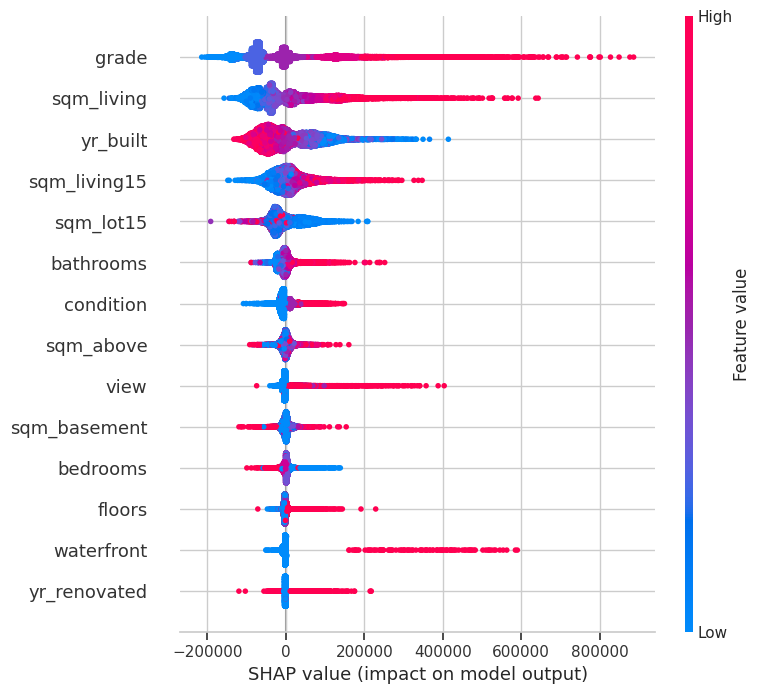

In [ ]:
import shap
import xgboost as xgb

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_cleaned.drop(columns='const'), label=Y_cleaned)
params = {'objective': 'reg:squarederror'}
bst = xgb.train(params, dtrain, num_boost_round=100)

# Calculate SHAP values
explainer = shap.TreeExplainer(bst)
shap_values = explainer.shap_values(X_cleaned.drop(columns='const'))

# Summary plot
shap.summary_plot(shap_values, X_cleaned.drop(columns='const'))

The scatter plots show:

* Positive relationships between price and variables like sqm_living, bathrooms, grade, and view, indicating that increases in these variables are associated with higher prices.
* Negative relationships, such as between price and bedrooms, suggesting a potential multicollinearity issue or an inverse impact when other factors are controlled.

This graph confirms and extends the results of the regression analysis, providing insight into how different characteristics affect home prices.

**Visualizing Nonlinear Relationships**

This scatter plot shows the relationship between house prices and square meters of living space (Sqm Living) with a polynomial regression line fitted to the data.

X-Axis: Represents the Sqm Living (square meters of living space).
Y-Axis: Represents the Price (in millions).
Blue Dots: Each dot represents a house, showing its living space and price.
Red Lines: These are the polynomial regression lines fitted to the data, indicating the predicted house prices based on the living space.



In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Polynomial regression model
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(model_df[['sqm_living']], model_df['price'])

# Scatter plot with polynomial regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sqm_living', y='price', data=model_df, alpha=0.5)
plt.plot(model_df['sqm_living'], poly_model.predict(df[['sqm_living']]), color='red')
plt.title('Price vs. Sqm Living with Polynomial Regression')
plt.xlabel('Sqm Living')
plt.ylabel('Price')
plt.show()

The scatterplot and polynomial regression lines show that home prices in the dataset increase with living space in a nonlinear manner. Polynomial regression captures this relationship better than a simple linear model, showing that the rate of price growth accelerates as living space increases. However, the wider range of data for higher residential properties suggests that additional factors will need to be taken into account to make more accurate price forecasts.

## Conclusion

The analysis shows that living area, property grade, bathrooms, waterfront location, view and several other property characteristics are associated with sale price. The initial regression explained about 65.4% of the observed price variation, while the model fitted after removing large-residual outliers increased R² to about 68.8%.

The diagnostics also highlight important limitations. Multicollinearity is present among several property-size variables, residual variance is not fully constant, and some prediction intervals are wide. The model should therefore be treated as an analytical demonstration rather than a production property-valuation system.

SHAP and polynomial regression were used as additional tools to explore feature effects and nonlinear relationships.